# 40K Points Regression & Maximum Damage Analysis

Analyzes the correlation between unit points costs and their abilities/statistics,
then finds the highest-damage combos against templated targets.

In [1]:
import json, os, re, math, warnings
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 200)

REPO = Path('/Users/will.mitchell/40kdc-data')
ARMY_ASSIST = Path(os.path.expanduser('~/army-assist/src/assets/json'))
DATA = REPO / 'data' / 'core'

print(f"Factions: {len([d for d in DATA.iterdir() if d.is_dir() and not d.name.startswith('_')])}")
print(f"Army-assist files: {len(list(ARMY_ASSIST.glob('*.json')))}")

Factions: 35
Army-assist files: 26


## Damage Engine

Rules-accurate 10th edition attack sequence. Key interactions:
- Lethal Hits + Devastating Wounds **don't combo** (auto-wound ≠ Critical Wound)
- Sustained Hits extra hits **don't get** Lethal Hits (only original crit benefits)
- Torrent = auto-hit = **no crits** possible
- Crits on **unmodified** rolls only; modifiers capped at ±1
- Overkill damage **lost** (no spillover to next model)
- DW mortal wounds **don't spill** on model death

In [2]:
def resolve_dice(val) -> float:
    """Convert a stat value (int, str dice expression) to expected value.
    Examples: 1 → 1.0, 'D6' → 3.5, '2D6' → 7.0, 'D6+1' → 4.5, 'D3' → 2.0, '2D3+1' → 5.0
    """
    if isinstance(val, (int, float)):
        return float(val)
    if val is None:
        return 0.0
    s = str(val).strip().upper()
    if not s or s in ('N/A', '-', '*', 'MELEE'):
        return 0.0
    # Try plain integer
    try:
        return float(s)
    except ValueError:
        pass
    # Parse dice: optional multiplier, D, sides, optional +/- constant
    m = re.match(r'^(\d*)D(\d+)\s*([+-]\s*\d+)?$', s)
    if m:
        count = int(m.group(1)) if m.group(1) else 1
        sides = int(m.group(2))
        bonus = int(m.group(3).replace(' ', '')) if m.group(3) else 0
        return count * (sides + 1) / 2.0 + bonus
    # Fallback
    try:
        return float(s)
    except ValueError:
        return 0.0


@dataclass
class TargetProfile:
    """Defensive profile of a target unit."""
    name: str
    models: int
    T: int
    W: int
    Sv: int
    invuln: Optional[int] = None  # e.g., 4 means 4+
    fnp: Optional[int] = None     # e.g., 5 means 5+
    damage_reduction: int = 0     # e.g., 1 for Necrodermis
    keywords: list = field(default_factory=list)


@dataclass
class Buffs:
    """Accumulated buffs from abilities, detachment, stratagems, leader, enhancement."""
    hit_mod: int = 0           # +1/-1 to hit (before capping)
    wound_mod: int = 0         # +1/-1 to wound (before capping)
    reroll_hits: str = 'none'  # 'none', '1s', 'all'
    reroll_wounds: str = 'none'
    reroll_damage: bool = False
    extra_attacks: int = 0
    extra_ap: int = 0          # improve AP by this much (positive = more negative AP)
    extra_strength: int = 0
    extra_damage: int = 0
    grant_lethal_hits: bool = False
    grant_sustained_hits: int = 0  # X value
    grant_devastating_wounds: bool = False
    grant_twin_linked: bool = False
    assume_stationary: bool = True   # for Heavy keyword
    assume_charged: bool = False     # for Lance keyword
    assume_half_range: bool = True   # for Melta/Rapid Fire (max damage scenario)


def parse_weapon_keywords(keywords: list[str]) -> dict:
    """Extract structured keyword effects from a weapon's keyword list.
    All comparisons are case-insensitive.
    """
    result = {
        'torrent': False,
        'blast': False,
        'lethal_hits': False,
        'sustained_hits': 0,
        'devastating_wounds': False,
        'twin_linked': False,
        'lance': False,
        'heavy': False,
        'rapid_fire': 0,
        'melta': 0,
        'indirect_fire': False,
        'ignores_cover': False,
        'precision': False,
        'extra_attacks': False,
        'anti': [],  # list of (keyword, threshold) tuples
        'hazardous': False,
        'assault': False,
        'pistol': False,
        'psychic': False,
        'one_shot': False,
    }
    for kw in keywords:
        kw_lower = kw.lower().strip()
        if kw_lower == 'torrent':
            result['torrent'] = True
        elif kw_lower == 'blast':
            result['blast'] = True
        elif kw_lower == 'lethal hits':
            result['lethal_hits'] = True
        elif kw_lower == 'devastating wounds':
            result['devastating_wounds'] = True
        elif kw_lower == 'twin-linked':
            result['twin_linked'] = True
        elif kw_lower == 'lance':
            result['lance'] = True
        elif kw_lower == 'heavy':
            result['heavy'] = True
        elif kw_lower == 'indirect fire':
            result['indirect_fire'] = True
        elif kw_lower == 'ignores cover':
            result['ignores_cover'] = True
        elif kw_lower == 'precision':
            result['precision'] = True
        elif kw_lower == 'extra attacks':
            result['extra_attacks'] = True
        elif kw_lower == 'hazardous':
            result['hazardous'] = True
        elif kw_lower == 'assault':
            result['assault'] = True
        elif kw_lower == 'pistol':
            result['pistol'] = True
        elif kw_lower == 'psychic':
            result['psychic'] = True
        elif kw_lower == 'one shot':
            result['one_shot'] = True
        else:
            # Sustained Hits X
            m = re.match(r'sustained hits (\d+|d\d+)', kw_lower)
            if m:
                result['sustained_hits'] = int(resolve_dice(m.group(1)))
                continue
            # Rapid Fire X
            m = re.match(r'rapid fire (\d+|d\d+)', kw_lower)
            if m:
                result['rapid_fire'] = int(resolve_dice(m.group(1)))
                continue
            # Melta X
            m = re.match(r'melta (\d+)', kw_lower)
            if m:
                result['melta'] = int(m.group(1))
                continue
            # Anti-KEYWORD X+
            m = re.match(r'anti-(.+?)\s+(\d+)\+', kw_lower)
            if m:
                anti_kw = m.group(1).strip()
                anti_threshold = int(m.group(2))
                result['anti'].append((anti_kw, anti_threshold))
                continue
    return result


def _clamp(val, lo, hi):
    return max(lo, min(hi, val))


def expected_damage(
    weapon_stats: dict,     # {A, BS or WS, S, AP, D} + keywords list
    weapon_type: str,       # 'ranged' or 'melee'
    n_models: int,          # number of attacking models
    target: TargetProfile,
    buffs: Buffs = None,
) -> dict:
    """Compute expected damage from a weapon profile against a target.
    
    Returns dict with:
      - 'models_killed' (for multi-model targets) or 'wounds_inflicted' (single model)
      - 'damage_per_model': damage from one attacking model
      - intermediate values for debugging
    """
    if buffs is None:
        buffs = Buffs()
    
    stats = weapon_stats
    kw = parse_weapon_keywords(stats.get('keywords', []))
    
    # --- STEP 1: Attack count ---
    base_A = resolve_dice(stats.get('A', 0)) + buffs.extra_attacks
    if kw['blast']:
        base_A += target.models // 5
    if kw['rapid_fire'] and buffs.assume_half_range:
        base_A += kw['rapid_fire']
    
    total_attacks = base_A * n_models
    if total_attacks <= 0:
        return {'models_killed': 0, 'wounds_inflicted': 0, 'damage_per_model': 0, 'total_attacks': 0}
    
    # --- STEP 2: Hit rolls ---
    skill_key = 'BS' if weapon_type == 'ranged' else 'WS'
    skill = stats.get(skill_key)
    if skill is None or skill == 0:
        if kw['torrent']:
            skill = 6  # won't matter, auto-hits
        else:
            return {'models_killed': 0, 'wounds_inflicted': 0, 'damage_per_model': 0, 'total_attacks': total_attacks}
    
    if kw['torrent']:
        normal_hits = total_attacks
        crit_hits = 0.0
    else:
        # Hit modifier: sum from buffs + Heavy, capped at +1/-1
        raw_hit_mod = buffs.hit_mod
        if kw['heavy'] and buffs.assume_stationary:
            raw_hit_mod += 1
        hit_mod = _clamp(raw_hit_mod, -1, 1)
        
        effective_bs = _clamp(skill - hit_mod, 2, 6)
        
        # P(miss) — nat 1 always misses
        p_miss = max(1, effective_bs - 1) / 6.0
        p_crit_hit = 1.0 / 6.0  # unmodified 6
        p_normal_hit = max(0.0, 1.0 - p_miss - p_crit_hit)
        
        # Rerolls (before modifiers)
        if buffs.reroll_hits == 'all':
            p_hit_total = p_normal_hit + p_crit_hit
            p_normal_hit += p_miss * (p_normal_hit / max(p_hit_total, 1e-9)) * p_hit_total
            p_crit_hit_new = p_crit_hit + p_miss * p_crit_hit
            p_normal_hit = p_normal_hit + p_miss * p_normal_hit - (p_crit_hit_new - p_crit_hit) * 0  # redo clean
            # Clean recalculation
            p_normal_hit_orig = max(0.0, 1.0 - max(1, effective_bs - 1) / 6.0 - 1.0/6.0)
            p_crit_orig = 1.0/6.0
            p_miss_orig = 1.0 - p_normal_hit_orig - p_crit_orig
            p_crit_hit = p_crit_orig + p_miss_orig * p_crit_orig
            p_normal_hit = p_normal_hit_orig + p_miss_orig * p_normal_hit_orig
        elif buffs.reroll_hits == '1s':
            # Reroll natural 1s only (1/6 chance of rolling a 1)
            p_reroll = 1.0 / 6.0
            p_normal_hit_orig = max(0.0, 1.0 - max(1, effective_bs - 1) / 6.0 - 1.0/6.0)
            p_crit_orig = 1.0/6.0
            p_crit_hit = p_crit_orig + p_reroll * p_crit_orig
            p_normal_hit = p_normal_hit_orig + p_reroll * p_normal_hit_orig
        
        normal_hits = total_attacks * p_normal_hit
        crit_hits = total_attacks * p_crit_hit
    
    # --- STEP 3: Process critical hits ---
    # Sustained Hits: use weapon's value OR buff's grant, whichever is higher (don't stack)
    sustained_x = max(kw['sustained_hits'], buffs.grant_sustained_hits)
    additional_hits = crit_hits * sustained_x  # auto-successful, need wound rolls
    
    # Lethal Hits
    has_lethal = kw['lethal_hits'] or buffs.grant_lethal_hits
    if has_lethal:
        auto_wounds = crit_hits  # bypass wound roll, NOT a Critical Wound
        hits_to_wound = normal_hits + additional_hits
    else:
        auto_wounds = 0.0
        hits_to_wound = normal_hits + crit_hits + additional_hits
    
    # --- STEP 4: Wound rolls ---
    S = resolve_dice(stats.get('S', 0)) + buffs.extra_strength
    T = target.T
    
    if S <= 0 or T <= 0:
        return {'models_killed': 0, 'wounds_inflicted': 0, 'damage_per_model': 0, 'total_attacks': total_attacks}
    
    if S >= 2 * T:
        wound_threshold = 2
    elif S > T:
        wound_threshold = 3
    elif S == T:
        wound_threshold = 4
    elif 2 * S >= T:  # S < T but S > T/2
        wound_threshold = 5
    else:  # S <= T/2
        wound_threshold = 6
    
    # Wound modifier: buffs + Lance, capped at +1/-1
    raw_wound_mod = buffs.wound_mod
    if kw['lance'] and buffs.assume_charged:
        raw_wound_mod += 1
    wound_mod = _clamp(raw_wound_mod, -1, 1)
    effective_wound = _clamp(wound_threshold - wound_mod, 2, 6)
    
    # Critical wound threshold (default 6, Anti-X can lower it)
    crit_wound_threshold = 6
    target_kw_lower = [k.lower() for k in target.keywords]
    for anti_kw, anti_val in kw['anti']:
        if anti_kw.lower() in target_kw_lower:
            crit_wound_threshold = min(crit_wound_threshold, anti_val)
    
    # Wound probabilities
    p_crit_wound = (7 - crit_wound_threshold) / 6.0
    p_wound_base = (7 - effective_wound) / 6.0
    # Natural 6 always wounds, natural 1 always fails
    p_wound_total = max(p_crit_wound, p_wound_base)
    p_non_crit_wound = max(0.0, p_wound_total - p_crit_wound)
    
    # Twin-linked or reroll wounds
    has_twin_linked = kw['twin_linked'] or buffs.grant_twin_linked
    if has_twin_linked or buffs.reroll_wounds == 'all':
        p_fail_wound = 1.0 - p_wound_total
        p_crit_wound_final = p_crit_wound + p_fail_wound * p_crit_wound
        p_non_crit_wound_final = p_non_crit_wound + p_fail_wound * p_non_crit_wound
    elif buffs.reroll_wounds == '1s':
        p_reroll = 1.0 / 6.0
        p_crit_wound_final = p_crit_wound + p_reroll * p_crit_wound
        p_non_crit_wound_final = p_non_crit_wound + p_reroll * p_non_crit_wound
    else:
        p_crit_wound_final = p_crit_wound
        p_non_crit_wound_final = p_non_crit_wound
    
    crit_wounds = hits_to_wound * p_crit_wound_final
    non_crit_wounds = hits_to_wound * p_non_crit_wound_final
    
    # --- STEP 5: Process critical wounds ---
    has_dw = kw['devastating_wounds'] or buffs.grant_devastating_wounds
    if has_dw:
        dw_wounds = crit_wounds  # mortal wounds, skip save
        normal_wounds = auto_wounds + non_crit_wounds
    else:
        dw_wounds = 0.0
        normal_wounds = auto_wounds + non_crit_wounds + crit_wounds
    
    # --- STEP 6: Saving throws (normal wounds only) ---
    AP = stats.get('AP', 0) - buffs.extra_ap  # extra_ap makes AP more negative
    modified_save = target.Sv - AP  # AP is negative, so Sv - (-2) = Sv + 2
    effective_save = modified_save
    if target.invuln is not None:
        effective_save = min(modified_save, target.invuln)
    
    p_save = _clamp((7 - effective_save) / 6.0, 0.0, 5.0/6.0)  # nat 1 fails
    p_fail_save = 1.0 - p_save
    
    unsaved_wounds = normal_wounds * p_fail_save
    
    # --- STEP 7: Inflict damage ---
    base_D = resolve_dice(stats.get('D', 0)) + buffs.extra_damage
    if kw['melta'] and buffs.assume_half_range:
        base_D += kw['melta']
    # Damage reduction (e.g., Necrodermis), min 1
    eff_D = max(base_D - target.damage_reduction, 1.0)
    
    # Reroll damage
    if buffs.reroll_damage and isinstance(stats.get('D'), str):
        # Approximate reroll: if dice, expected value is higher
        # E[max(D, D)] ≈ E[D] * 1.167 for D6, but "reroll damage" typically means
        # reroll the whole damage roll. Simplification: +16.7% for D6, +12.5% for D3
        raw_D = resolve_dice(stats.get('D', 0))
        eff_D = max(raw_D * 1.167 + buffs.extra_damage + (kw['melta'] if buffs.assume_half_range else 0) - target.damage_reduction, 1.0)
    
    # FNP
    p_fnp = (7 - target.fnp) / 6.0 if target.fnp else 0.0
    fnp_passthrough = 1.0 - p_fnp
    
    # --- Compute kills / wounds ---
    if target.models > 1:
        # Multi-model target: account for overkill waste
        # effective_D_per_wound accounts for FNP on each wound point
        eff_D_after_fnp = eff_D * fnp_passthrough
        if eff_D_after_fnp > 0:
            wounds_per_kill = math.ceil(target.W / eff_D_after_fnp)
        else:
            wounds_per_kill = float('inf')
        normal_kills = unsaved_wounds / wounds_per_kill if wounds_per_kill > 0 else 0
        
        # DW path: mortal wounds, no save, no spill on model death
        dw_eff = min(eff_D, target.W) * fnp_passthrough
        dw_kills = dw_wounds * dw_eff / target.W if target.W > 0 else 0
        
        total_kills = min(normal_kills + dw_kills, target.models)
        return {
            'models_killed': total_kills,
            'wounds_inflicted': total_kills * target.W,  # proxy
            'damage_per_model': (normal_kills + dw_kills) * target.W / n_models if n_models > 0 else 0,
            'total_attacks': total_attacks,
            'unsaved_wounds': unsaved_wounds,
            'dw_wounds': dw_wounds,
        }
    else:
        # Single model target
        normal_dmg = unsaved_wounds * eff_D * fnp_passthrough
        dw_dmg = dw_wounds * eff_D * fnp_passthrough
        total_wounds = min(normal_dmg + dw_dmg, target.W)
        return {
            'models_killed': 1.0 if total_wounds >= target.W else 0.0,
            'wounds_inflicted': total_wounds,
            'damage_per_model': (normal_dmg + dw_dmg) / n_models if n_models > 0 else 0,
            'total_attacks': total_attacks,
            'unsaved_wounds': unsaved_wounds,
            'dw_wounds': dw_wounds,
        }

print("Damage engine defined.")

Damage engine defined.


In [3]:
# --- Damage Engine Unit Tests ---

guardsman = TargetProfile("Guardsman", models=20, T=3, W=1, Sv=5)
intercessor = TargetProfile("Intercessor", models=10, T=4, W=2, Sv=3)
terminator = TargetProfile("Terminator", models=5, T=5, W=3, Sv=2, invuln=4, keywords=['Infantry', 'Terminator'])
armiger = TargetProfile("Armiger", models=1, T=9, W=14, Sv=3, invuln=5, keywords=['Vehicle', 'Walker'])
nightbringer = TargetProfile("Nightbringer", models=1, T=11, W=16, Sv=3, invuln=4,
                             fnp=5, damage_reduction=1, keywords=['Monster', 'Character'])

no_buffs = Buffs(assume_stationary=True, assume_half_range=True)

# Test 1: Bolter vs Guardsman
# 1 shot, BS3+, S4, AP0, D1 vs T3/Sv5+
# Hit: 4/6, Wound (S4>T3 → 3+): 4/6, Save (5+ with AP0 → 5+, fails 4/6), D=1
# Expected: 4/6 * 4/6 * 4/6 * 1 = 64/216 ≈ 0.296
bolter = {'A': 1, 'BS': 3, 'S': 4, 'AP': 0, 'D': 1, 'keywords': []}
r = expected_damage(bolter, 'ranged', 1, guardsman, no_buffs)
print(f"Bolter vs guardsman: {r['models_killed']:.4f} kills (expected ~0.296)")
assert abs(r['models_killed'] - 64/216) < 0.01, f"Got {r['models_killed']}"

# Test 2: Lascannon vs Armiger
# 1 shot, BS3+, S12, AP-3, D(D6+1=4.5) vs T9/Sv3+/5++
# Hit: 4/6, Wound (S12>T9 → 3+): 4/6
# Save: modified = 3-(-3)=6+, invuln=5+; use 5+. P(save)=2/6, P(fail)=4/6
# D=4.5
# Expected: 4/6 * 4/6 * 4/6 * 4.5 = 1.333
lascannon = {'A': 1, 'BS': 3, 'S': 12, 'AP': -3, 'D': 'D6+1', 'keywords': []}
r = expected_damage(lascannon, 'ranged', 1, armiger, no_buffs)
print(f"Lascannon vs armiger: {r['wounds_inflicted']:.3f} wounds (expected ~1.333)")
assert abs(r['wounds_inflicted'] - 4/6 * 4/6 * 4/6 * 4.5) < 0.05

# Test 3: Multi-melta at half range vs Armiger (Melta 2)
# 1 shot, BS3+, S9, AP-4, D(D6+2=5.5) + Melta 2 = 7.5 vs T9/Sv3+/5++
# Hit: 4/6, Wound (S9=T9 → 4+): 3/6
# Save: 3-(-4)=7+, invuln=5+; use 5+. P(fail)=4/6
# Expected: 4/6 * 3/6 * 4/6 * 7.5 ≈ 1.667
multimelta = {'A': 1, 'BS': 3, 'S': 9, 'AP': -4, 'D': 'D6+2', 'keywords': ['Melta 2']}
r = expected_damage(multimelta, 'ranged', 1, armiger, no_buffs)
print(f"Multi-melta vs armiger: {r['wounds_inflicted']:.3f} wounds (expected ~1.667)")
assert abs(r['wounds_inflicted'] - 4/6 * 3/6 * 4/6 * 7.5) < 0.05

# Test 4: Torrent weapon — should produce 0 crit hits
flamer = {'A': 'D6', 'BS': None, 'S': 4, 'AP': 0, 'D': 1, 'keywords': ['Torrent', 'Ignores Cover']}
r = expected_damage(flamer, 'ranged', 1, guardsman, no_buffs)
# 3.5 auto-hits, wound 3+ (4/6), save 5+ fails 4/6, D1
# 3.5 * 4/6 * 4/6 = 1.556
print(f"Flamer vs guardsman: {r['models_killed']:.3f} kills (expected ~1.556)")
assert abs(r['models_killed'] - 3.5 * 4/6 * 4/6) < 0.05

# Test 5: Lethal Hits + Devastating Wounds DON'T COMBO
# Weapon with both: crit hits auto-wound via Lethal, but auto-wound ≠ crit wound, so DW never fires
# Use a simple weapon: 6 attacks, BS2+, S4, AP-1, D2
# With both LH+DW: the crit hits should auto-wound and go to save, NOT bypass save
dw_lh_weapon = {'A': 6, 'BS': 2, 'S': 4, 'AP': -1, 'D': 2,
                 'keywords': ['Lethal Hits', 'Devastating Wounds']}
r = expected_damage(dw_lh_weapon, 'ranged', 1, terminator, no_buffs)
# DW should be 0 since Lethal auto-wounds are not Critical Wounds
# The wound roll crits from normal+sustained hits CAN trigger DW, but lethal hits
# intercept the crit hits before wound roll.
# With Lethal: crit hits (1/6 of 6 = 1 attack) → auto-wound → save
# Non-crit hits (4/6 of 6 = 4) → wound roll → some crit wounds trigger DW
# So DW should fire from wound roll crits of the 4 normal hits, not from lethal
print(f"LH+DW: dw_wounds={r['dw_wounds']:.3f} (should be from wound roll crits of non-lethal hits only)")
# Verify: 4 normal hits * p_crit_wound(1/6) = 0.667 DW wounds
assert r['dw_wounds'] > 0, "DW should still fire from wound roll crits of non-lethal hits"
print(f"  (4 normal hits need wound rolls, their crit wounds trigger DW: {r['dw_wounds']:.3f})")

# Test 6: Blast against horde (+1A per 5 models)
heavy_bolter = {'A': 3, 'BS': 3, 'S': 5, 'AP': -1, 'D': 2, 'keywords': ['Blast', 'Heavy']}
r = expected_damage(heavy_bolter, 'ranged', 1, guardsman, no_buffs)
# Blast: +20//5 = +4A → 7 attacks total, Heavy: +1 to hit (BS3+ → 2+)
print(f"Heavy bolter (blast) vs 20 guardsmen: {r['total_attacks']:.0f} attacks, {r['models_killed']:.2f} kills")
assert r['total_attacks'] == 7  # 3 base + 4 blast

# Test 7: D2 weapon vs W1 target — overkill waste
# Each unsaved wound kills 1 model (D=2 but W=1, excess wasted)
plasma = {'A': 2, 'BS': 3, 'S': 7, 'AP': -2, 'D': 2, 'keywords': []}
r = expected_damage(plasma, 'ranged', 1, guardsman, no_buffs)
# Hit 4/6, Wound (S7>=2*T3 → 2+) 5/6, Save (5-(-2)=7+ → auto-fail): 6/6, D2 but W1
# Each unsaved wound kills 1 model. wounds_per_kill = ceil(1/2) = 1
# kills = unsaved / 1 = 4/6 * 5/6 * 1 = 20/36 ≈ 0.556 per attack, × 2A = 1.111
print(f"Plasma vs guardsman: {r['models_killed']:.3f} kills (D2 wasted on W1, expect ~1.111)")
assert abs(r['models_killed'] - 2 * 4/6 * 5/6 * 1.0) < 0.05

# Test 8: Nightbringer's defenses (FNP 5+, -1D)
# Lascannon D6+1 (4.5) → -1D → 3.5 eff_D, then FNP 5+ (2/3 pass through)
# Wound throughput: 4/6 hit * wound(S12 vs T11: S>T → 3+) 4/6 * save(invuln 4+, fail 3/6)
# = 4/6 * 4/6 * 3/6 = 0.222 unsaved wounds
# Damage: 0.222 * 3.5 * 2/3 = 0.519
r = expected_damage(lascannon, 'ranged', 1, nightbringer, no_buffs)
expected_w = 4/6 * 4/6 * 3/6 * (4.5-1) * 2/3
print(f"Lascannon vs Nightbringer: {r['wounds_inflicted']:.3f} wounds (expected ~{expected_w:.3f})")
assert abs(r['wounds_inflicted'] - expected_w) < 0.05

print("\n✓ All damage engine tests passed!")

Bolter vs guardsman: 0.2963 kills (expected ~0.296)
Lascannon vs armiger: 1.333 wounds (expected ~1.333)
Multi-melta vs armiger: 1.667 wounds (expected ~1.667)
Flamer vs guardsman: 1.556 kills (expected ~1.556)
LH+DW: dw_wounds=0.667 (should be from wound roll crits of non-lethal hits only)
  (4 normal hits need wound rolls, their crit wounds trigger DW: 0.667)
Heavy bolter (blast) vs 20 guardsmen: 7 attacks, 3.24 kills
Plasma vs guardsman: 1.111 kills (D2 wasted on W1, expect ~1.111)
Lascannon vs Nightbringer: 0.519 wounds (expected ~0.519)

✓ All damage engine tests passed!


## Data Loading

Load all structured data from 40kdc-data and ability/stratagem text from army-assist.
Join via name → `name_to_id()` matching.

In [4]:
import unicodedata

def name_to_id(name: str) -> str:
    """Replicate the TypeScript nameToId transform: NFD normalize, strip diacritics,
    lowercase, replace non-alphanumeric with hyphens, collapse multiple hyphens,
    strip leading/trailing hyphens."""
    s = unicodedata.normalize('NFD', name)
    s = ''.join(c for c in s if unicodedata.category(c) != 'Mn')  # strip diacritics
    s = s.lower()
    s = re.sub(r'[^a-z0-9]+', '-', s)  # non-alphanumeric → hyphen
    s = re.sub(r'-+', '-', s)  # collapse
    s = s.strip('-')
    return s

# --- Load 40kdc-data ---
factions_list = sorted([d.name for d in DATA.iterdir() if d.is_dir() and not d.name.startswith('_')])

def load_faction_json(faction: str, filename: str):
    path = DATA / faction / filename
    if path.exists():
        with open(path) as f:
            return json.load(f)
    return []

all_units = []
all_weapons = {}  # keyed by (faction_id, weapon_id) for dedup
all_detachments = []
all_enhancements = []
all_stratagems = []
all_leader_attachments = []
all_unit_compositions = []

for faction in factions_list:
    for u in load_faction_json(faction, 'units.json'):
        u['_faction'] = faction
        all_units.append(u)
    for w in load_faction_json(faction, 'weapons.json'):
        key = (faction, w['id'])
        all_weapons[key] = w
    for d in load_faction_json(faction, 'detachments.json'):
        d['_faction'] = faction
        all_detachments.append(d)
    for e in load_faction_json(faction, 'enhancements.json'):
        e['_faction'] = faction
        all_enhancements.append(e)
    for s in load_faction_json(faction, 'stratagems.json'):
        s['_faction'] = faction
        all_stratagems.append(s)
    for la in load_faction_json(faction, 'leader-attachments.json'):
        la['_faction'] = faction
        all_leader_attachments.append(la)
    for uc in load_faction_json(faction, 'unit-compositions.json'):
        uc['_faction'] = faction
        all_unit_compositions.append(uc)

# Build weapon lookup: faction → weapon_id → weapon data
weapon_lookup = {}
for (faction, wid), w in all_weapons.items():
    weapon_lookup.setdefault(faction, {})[wid] = w

# Build leader attachment lookup: bodyguard_id → [leader_ids]
bodyguard_leaders = {}  # (faction, bodyguard_id) → [leader_id, ...]
leader_bodyguards = {}  # (faction, leader_id) → [bodyguard_id, ...]
for la in all_leader_attachments:
    faction = la['_faction']
    lid = la['leader_id']
    for bid in la.get('eligible_bodyguard_ids', []):
        bodyguard_leaders.setdefault((faction, bid), []).append(lid)
        leader_bodyguards.setdefault((faction, lid), []).append(bid)

# Unit lookup by (faction, id)
unit_lookup = {(u['_faction'], u['id']): u for u in all_units}

print(f"Loaded {len(all_units)} units, {len(all_weapons)} weapon entries, "
      f"{len(all_detachments)} detachments, {len(all_enhancements)} enhancements, "
      f"{len(all_stratagems)} stratagems, {len(all_leader_attachments)} leader attachments")

Loaded 1183 units, 2360 weapon entries, 190 detachments, 754 enhancements, 1140 stratagems, 308 leader attachments


In [5]:
# --- Load army-assist data ---
def load_army_assist(filename):
    with open(ARMY_ASSIST / filename) as f:
        return json.load(f)

aa_datasheets = load_army_assist('Datasheets.json')
aa_abilities = load_army_assist('Datasheets_abilities.json')
aa_global_abilities = load_army_assist('Abilities.json')
aa_stratagems = load_army_assist('Stratagems.json')
aa_enhancements = load_army_assist('Enhancements.json')
aa_detachment_abilities = load_army_assist('Detachment_abilities.json')

# Build army-assist lookups
aa_ds_by_id = {ds['id']: ds for ds in aa_datasheets}
aa_abilities_by_ds = {}  # datasheet_id → [abilities]
for ab in aa_abilities:
    aa_abilities_by_ds.setdefault(ab['datasheet_id'], []).append(ab)

# Map army-assist datasheet names to 40kdc IDs
aa_name_to_dsid = {}  # name_to_id(name) → datasheet_id
for ds in aa_datasheets:
    nid = name_to_id(ds['name'])
    aa_name_to_dsid[nid] = ds['id']

# Join: for each 40kdc unit, find matching army-assist datasheet
unit_abilities = {}  # (faction, unit_id) → [abilities from army-assist]
matched = 0
unmatched = 0
for u in all_units:
    uid = u['id']
    faction = u['_faction']
    # Try direct name_to_id match
    dsid = aa_name_to_dsid.get(uid)
    if dsid and dsid in aa_abilities_by_ds:
        unit_abilities[(faction, uid)] = aa_abilities_by_ds[dsid]
        matched += 1
    else:
        unit_abilities[(faction, uid)] = []
        unmatched += 1

print(f"Army-assist data: {len(aa_datasheets)} datasheets, {len(aa_abilities)} ability entries")
print(f"Join results: {matched} matched, {unmatched} unmatched ({matched/(matched+unmatched)*100:.1f}% hit rate)")

# Build detachment abilities lookup: (faction_id, detachment_name) → description
aa_det_abilities_lookup = {}  # faction_id → detachment_name → [abilities]
for da in aa_detachment_abilities:
    fid = da.get('faction_id', '')
    det = da.get('detachment', '')
    aa_det_abilities_lookup.setdefault(fid, {}).setdefault(det, []).append(da)

# Build stratagems lookup: faction_id → detachment → [stratagems]
aa_strat_lookup = {}
for s in aa_stratagems:
    fid = s.get('faction_id', '')
    det = s.get('detachment', '')
    aa_strat_lookup.setdefault(fid, {}).setdefault(det, []).append(s)

# Build enhancements lookup: faction_id → detachment → [enhancements]
aa_enh_lookup = {}
for e in aa_enhancements:
    fid = e.get('faction_id', '')
    det = e.get('detachment', '')
    aa_enh_lookup.setdefault(fid, {}).setdefault(det, []).append(e)

# Build faction rules lookup: faction_id → [faction abilities]
aa_faction_rules = {}
for ab in aa_global_abilities:
    fid = ab.get('faction_id', '')
    aa_faction_rules.setdefault(fid, []).append(ab)

print(f"Detachment abilities: {len(aa_detachment_abilities)} entries across {len(aa_det_abilities_lookup)} factions")
print(f"Stratagems: {len(aa_stratagems)} entries")
print(f"Enhancements: {len(aa_enhancements)} entries")
print(f"Faction rules: {sum(len(v) for v in aa_faction_rules.values())} entries")

Army-assist data: 1184 datasheets, 5017 ability entries
Join results: 1166 matched, 17 unmatched (98.6% hit rate)
Detachment abilities: 206 entries across 23 factions
Stratagems: 1151 entries
Enhancements: 754 entries
Faction rules: 55 entries


## Buff Extraction Engine

Regex-based extraction of mechanical effects from ability/stratagem/enhancement/detachment
descriptions. Distinguishes reroll-all vs reroll-1s (dramatically different value per the rules).

In [6]:
def extract_buffs_from_text(description: str) -> dict:
    """Extract structured buff effects from an ability/stratagem description.
    Returns dict of buff type -> value/True/False.
    Uses [^.]* instead of .* to prevent matching across sentence boundaries.
    
    Reroll classification:
    - "re-roll hit rolls" (plural, no qualifier) -> reroll ALL hits
    - "re-roll the Hit roll" (the = each attack's) -> reroll ALL hits
    - "re-roll a/one Hit roll" (singular indefinite) -> reroll ONE (~Command Re-roll, skipped)
    - "re-roll hit rolls of 1" -> reroll 1s only
    """
    if not description:
        return {}
    d = description.lower()
    buffs = {}
    
    # --- Hit rerolls ---
    # "re-roll a/one hit roll" = single reroll per phase (weak, ~Command Re-roll)
    # We skip these -- they're not meaningful enough to model as a persistent buff.
    # "re-roll hit rolls" (plural) or "re-roll the hit roll" = reroll ALL
    # "re-roll hit rolls of 1" = reroll 1s
    if re.search(r're-roll[^.]*hit rolls? of 1', d):
        buffs['reroll_hits_1s'] = True
    elif re.search(r're-roll[^.]*(?:the |all )?hit rolls(?! of [12])', d):
        # Plural "rolls" -- this is reroll all hits
        buffs['reroll_hits_all'] = True
    elif re.search(r're-roll the hit roll(?! of)', d):
        # "the hit roll" (singular definite) = each attack can reroll = reroll all
        buffs['reroll_hits_all'] = True
    # Note: "re-roll a hit roll" and "re-roll one hit roll" are intentionally
    # NOT captured -- they're single rerolls per phase, not persistent buffs.
    
    # --- Wound rerolls (same logic) ---
    if re.search(r're-roll[^.]*wound rolls? of 1', d):
        buffs['reroll_wounds_1s'] = True
    elif re.search(r're-roll[^.]*(?:the |all )?wound rolls(?! of [12])', d):
        buffs['reroll_wounds_all'] = True
    elif re.search(r're-roll the wound roll(?! of)', d):
        buffs['reroll_wounds_all'] = True
    
    # --- Other hit/wound modifiers ---
    m = re.search(r'add (\d+) to[^.]*hit roll', d)
    if m:
        buffs['plus_to_hit'] = int(m.group(1))
    m = re.search(r'subtract (\d+) from[^.]*hit roll', d)
    if m:
        buffs['minus_to_hit'] = int(m.group(1))
    m = re.search(r'add (\d+) to[^.]*wound roll', d)
    if m:
        buffs['plus_to_wound'] = int(m.group(1))
    m = re.search(r'subtract (\d+) from[^.]*wound roll', d)
    if m:
        buffs['minus_to_wound'] = int(m.group(1))
    
    # --- Damage modifiers ---
    if re.search(r're-roll[^.]*(?:the |all )?damage roll', d):
        buffs['reroll_damage'] = True
    m = re.search(r'subtract (\d+) from the damage', d)
    if m:
        buffs['damage_reduction'] = int(m.group(1))
    
    # --- Keyword grants ---
    if re.search(r'\[?lethal hits\]?', d):
        buffs['grant_lethal_hits'] = True
    m = re.search(r'\[?sustained hits (\d+)\]?', d)
    if m:
        buffs['grant_sustained_hits'] = int(m.group(1))
    if re.search(r'\[?devastating wounds\]?', d):
        buffs['grant_devastating_wounds'] = True
    
    # --- Attack/stat modifiers ---
    m = re.search(r'(?:add|gets?) (\d+)[^.]*(?:additional|extra) attack', d)
    if m:
        buffs['extra_attacks'] = int(m.group(1))
    m2 = re.search(r'add (\d+) to the attacks characteristic', d)
    if m2:
        buffs['extra_attacks'] = int(m2.group(1))
    m = re.search(r'improve[^.]*armour penetration[^.]*by (\d+)', d)
    if m:
        buffs['extra_ap'] = int(m.group(1))
    m = re.search(r'add (\d+) to the strength', d)
    if m:
        buffs['extra_strength'] = int(m.group(1))
    
    # --- Defensive buffs ---
    m = re.search(r'feel no pain (\d+)\+', d)
    if m:
        buffs['feel_no_pain'] = int(m.group(1))
    m = re.search(r'invulnerable save[^.]*?(\d+)\+', d)
    if m:
        buffs['invuln_save'] = int(m.group(1))
    
    # --- Special ---
    if re.search(r'fights? first', d):
        buffs['fight_first'] = True
    if re.search(r'(?:mortal wounds?)', d):
        buffs['has_mortal_output'] = True
    if re.search(r'(?:wound rolls? of 1-3 always fail|irrespective of)', d):
        buffs['transhuman'] = True
    if re.search(r'ignores? cover', d):
        buffs['ignores_cover'] = True
    
    # --- Expanded patterns for faction rules and unit abilities ---
    # "add 1 to the Attacks characteristics" (Waaagh!, various)
    m = re.search(r'add (\d+) to the[^.]*attacks characteristic', d)
    if m:
        buffs['extra_attacks'] = max(buffs.get('extra_attacks', 0), int(m.group(1)))
    # "add 1 to the Strength characteristics" (Waaagh!)
    m = re.search(r'add (\d+) to the[^.]*strength characteristic', d)
    if m:
        buffs['extra_strength'] = max(buffs.get('extra_strength', 0), int(m.group(1)))
    # Keyword grants from faction rules: "[SUSTAINED HITS 1] ability" or "gain the [LETHAL HITS]"
    if re.search(r'(?:gain|have)[^.]*\[?lethal hits\]?[^.]*ability', d):
        buffs['grant_lethal_hits'] = True
    m = re.search(r'(?:gain|have)[^.]*\[?sustained hits (\d+)\]?[^.]*ability', d)
    if m:
        buffs['grant_sustained_hits'] = max(buffs.get('grant_sustained_hits', 0), int(m.group(1)))
    # "subtract 1 from the Toughness characteristic" (Nurgle's Gift on enemies = effective +1 wound)
    if re.search(r'subtract \d+ from[^.]*toughness characteristic', d):
        buffs['plus_to_wound'] = max(buffs.get('plus_to_wound', 0), 1)
    # Dark Pacts: choose Lethal Hits or Sustained Hits 1 — take the better one (Lethal)
    if re.search(r'select one of the following.*lethal hits', d):
        buffs['grant_lethal_hits'] = True
    # "can re-roll the Wound roll" (singular definite = reroll all, like Oath of Moment pattern)
    if re.search(r'can re-roll the wound roll(?! of)', d):
        buffs['reroll_wounds_all'] = True
    # "can re-roll the Hit roll" (e.g., Oath of Moment in full description)
    if re.search(r'can re-roll the hit roll(?! of)', d):
        buffs['reroll_hits_all'] = True
    
    return buffs


def text_to_buffs_object(descriptions: list[str], phase: str = 'shooting') -> Buffs:
    """Combine buff extractions from multiple description texts into a Buffs object.
    Respects stacking rules: same buff from multiple sources -> use best, not sum.
    Hit/wound mods capped at +1/-1.
    """
    b = Buffs()
    for desc in descriptions:
        extracted = extract_buffs_from_text(desc)
        if extracted.get('reroll_hits_all'):
            b.reroll_hits = 'all'
        elif extracted.get('reroll_hits_1s') and b.reroll_hits != 'all':
            b.reroll_hits = '1s'
        if extracted.get('reroll_wounds_all'):
            b.reroll_wounds = 'all'
        elif extracted.get('reroll_wounds_1s') and b.reroll_wounds != 'all':
            b.reroll_wounds = '1s'
        if extracted.get('reroll_damage'):
            b.reroll_damage = True
        if extracted.get('plus_to_hit'):
            b.hit_mod = max(b.hit_mod, extracted['plus_to_hit'])
        if extracted.get('plus_to_wound'):
            b.wound_mod = max(b.wound_mod, extracted['plus_to_wound'])
        if extracted.get('extra_attacks'):
            b.extra_attacks += extracted['extra_attacks']
        if extracted.get('extra_ap'):
            b.extra_ap = max(b.extra_ap, extracted['extra_ap'])
        if extracted.get('extra_strength'):
            b.extra_strength = max(b.extra_strength, extracted['extra_strength'])
        if extracted.get('grant_lethal_hits'):
            b.grant_lethal_hits = True
        if extracted.get('grant_sustained_hits'):
            b.grant_sustained_hits = max(b.grant_sustained_hits, extracted['grant_sustained_hits'])
        if extracted.get('grant_devastating_wounds'):
            b.grant_devastating_wounds = True
        if extracted.get('grant_twin_linked'):
            b.grant_twin_linked = True
    return b


# --- Map 40kdc faction IDs to army-assist faction codes ---
FOURTYDC_TO_AA = {
    'adepta-sororitas': 'AS', 'adeptus-astartes': 'SM', 'adeptus-custodes': 'AC',
    'adeptus-mechanicus': 'AdM', 'aeldari': 'AE', 'agents-of-the-imperium': 'AoI',
    'astra-militarum': 'AM', 'black-templars': 'SM', 'blood-angels': 'SM',
    'chaos-daemons': 'CD', 'chaos-knights': 'QI', 'chaos-space-marines': 'CSM',
    'crimson-fists': 'SM', 'dark-angels': 'SM', 'death-guard': 'DG',
    'deathwatch': 'SM', 'drukhari': 'DRU', 'emperors-children': 'EC',
    'genestealer-cults': 'GC', 'grey-knights': 'GK', 'imperial-fists': 'SM',
    'imperial-knights': 'QT', 'iron-hands': 'SM', 'leagues-of-votann': 'LoV',
    'necrons': 'NEC', 'orks': 'ORK', 'raven-guard': 'SM',
    'salamanders': 'SM', 'space-wolves': 'SM', 'tau-empire': 'TAU',
    'thousand-sons': 'TS', 'tyranids': 'TYR', 'ultramarines': 'SM',
    'white-scars': 'SM', 'world-eaters': 'WE',
}

# Verify the fix
print("Reroll regex tests:")
tests = [
    ("re-roll one Hit roll, one Wound roll or one Damage roll", "Ironstorm -> should be EMPTY"),
    ("re-roll the Hit roll", "Oath of Moment -> should be reroll_hits_all"),
    ("re-roll a Hit roll of 1", "Captain aura -> should be reroll_hits_1s"),
    ("re-roll hit rolls", "Generic full reroll -> should be reroll_hits_all"),
    ("you can re-roll the Hit roll", "Oath expanded -> should be reroll_hits_all"),
    ("re-roll a Wound roll of 1", "Lieutenant -> should be reroll_wounds_1s"),
    ("re-roll wound rolls", "Full wound rerolls -> should be reroll_wounds_all"),
]
for text, expected in tests:
    result = extract_buffs_from_text(text)
    reroll_keys = {k: v for k, v in result.items() if 'reroll' in k}
    print(f"  {str(reroll_keys) if reroll_keys else '{}':<40s} <- {expected}")


Reroll regex tests:
  {'reroll_damage': True}                  <- Ironstorm -> should be EMPTY
  {'reroll_hits_all': True}                <- Oath of Moment -> should be reroll_hits_all
  {'reroll_hits_1s': True}                 <- Captain aura -> should be reroll_hits_1s
  {'reroll_hits_all': True}                <- Generic full reroll -> should be reroll_hits_all
  {'reroll_hits_all': True}                <- Oath expanded -> should be reroll_hits_all
  {'reroll_wounds_1s': True}               <- Lieutenant -> should be reroll_wounds_1s
  {'reroll_wounds_all': True}              <- Full wound rerolls -> should be reroll_wounds_all


In [7]:
# --- Load Ability DSL data ---
# Prefer structured DSL from enrichment/ where available, fall back to regex extraction

def load_dsl_abilities():
    """Load all ability DSL files from enrichment directories."""
    dsl_by_faction = {}  # faction → [abilities]
    enrichment_dir = REPO / 'data' / 'enrichment'
    for faction_dir in sorted(enrichment_dir.iterdir()):
        if not faction_dir.is_dir() or faction_dir.name.startswith('_'):
            continue
        ab_path = faction_dir / 'abilities.json'
        if ab_path.exists():
            with open(ab_path) as f:
                dsl_by_faction[faction_dir.name] = json.load(f)
    return dsl_by_faction

dsl_abilities = load_dsl_abilities()
print(f"Loaded DSL abilities for {len(dsl_abilities)} factions, "
      f"{sum(len(v) for v in dsl_abilities.values())} total entries")

# Build lookup: (faction, unit_id) -> [DSL abilities]
dsl_by_unit = {}  # (faction, unit_id) -> [abilities]
dsl_by_faction_rule = {}  # faction -> [faction-type abilities]
for faction, abilities_list in dsl_abilities.items():
    for ab in abilities_list:
        ab_type = ab.get('ability_type', '')
        if ab_type == 'faction':
            dsl_by_faction_rule.setdefault(faction, []).append(ab)
        for uid in ab.get('unit_ids', []):
            dsl_by_unit.setdefault((faction, uid), []).append(ab)


def is_offensive_effect(effect):
    """Check if an effect is offensive (modifies our attacks, not enemy attacks on us)."""
    if not effect:
        return False
    target = effect.get('target', '')
    # Defensive targets: attacker hitting us, self-protection
    if target in ('attacker',):
        return False
    etype = effect.get('type', '')
    # Defensive effect types
    if etype in ('feel-no-pain', 'invulnerable-save', 'ward', 'damage-reduction',
                 'attack-restriction', 'leadership-modifier', 'objective-control-modifier'):
        return False
    # Roll modifiers that subtract from enemy rolls (defensive)
    if etype == 'roll-modifier':
        mod = effect.get('modifier', {})
        if mod.get('operation') == 'subtract' and target in ('attacker', 'enemy-within-aura'):
            return False
    return True


def walk_effect_to_buffs(effect, buffs):
    """Recursively walk a DSL effect tree, applying offensive effects to a Buffs object.
    Assumes all conditions are met (hill-climbing mode). Skips defensive effects.
    """
    if not effect:
        return
    
    etype = effect.get('type', '')
    
    # --- Composite effects ---
    if etype == 'conditional':
        # Assume condition is met (hill-climbing)
        walk_effect_to_buffs(effect.get('effect'), buffs)
        return
    
    if etype == 'sequence':
        for step in effect.get('steps', []):
            walk_effect_to_buffs(step, buffs)
        return
    
    if etype == 'choice':
        # Score each option and pick the best for offense
        best_option = None
        best_score = -1
        for opt in effect.get('options', []):
            score = _score_offensive_effect(opt)
            if score > best_score:
                best_score = score
                best_option = opt
        if best_option:
            walk_effect_to_buffs(best_option, buffs)
        return
    
    if etype == 'dice-gated':
        # Assume success for offensive effects
        on_success = effect.get('on_success')
        if on_success and is_offensive_effect(on_success):
            walk_effect_to_buffs(on_success, buffs)
        return
    
    if etype == 'dice-pool-allocation':
        # Pick the best N options (N = max_activations)
        max_act = effect.get('max_activations', 1)
        options = effect.get('options', [])
        scored = [(i, _score_offensive_effect(opt.get('effect', {}))) for i, opt in enumerate(options)]
        scored.sort(key=lambda x: x[1], reverse=True)
        for idx, _ in scored[:max_act]:
            walk_effect_to_buffs(options[idx].get('effect', {}), buffs)
        return
    
    # --- Skip defensive effects ---
    if not is_offensive_effect(effect):
        return
    
    # --- Single effects ---
    mod = effect.get('modifier', {})
    
    if etype == 'stat-modifier':
        stat = mod.get('stat', '')
        op = mod.get('operation', 'add')
        val = mod.get('value', 0)
        if not stat or not val:
            return  # stub, skip
        if stat == 'A' and op == 'add':
            buffs.extra_attacks += val
        elif stat == 'S' and op == 'add':
            buffs.extra_strength = max(buffs.extra_strength, val)
        elif stat == 'AP' and op == 'add':
            buffs.extra_ap = max(buffs.extra_ap, abs(val))
    
    elif etype == 'roll-modifier':
        roll = mod.get('roll', '')
        op = mod.get('operation', 'add')
        val = mod.get('value', 0)
        if roll == 'hit' and op == 'add':
            buffs.hit_mod = max(buffs.hit_mod, val)
        elif roll == 'wound' and op == 'add':
            buffs.wound_mod = max(buffs.wound_mod, val)
    
    elif etype == 're-roll':
        roll = mod.get('roll', '')
        condition = mod.get('condition', '')
        if roll == 'hit':
            if condition == 'any-fail':
                buffs.reroll_hits = 'all'
            elif condition == 'natural-1' and buffs.reroll_hits != 'all':
                buffs.reroll_hits = '1s'
        elif roll == 'wound':
            if condition == 'any-fail':
                buffs.reroll_wounds = 'all'
            elif condition == 'natural-1' and buffs.reroll_wounds != 'all':
                buffs.reroll_wounds = '1s'
        elif roll == 'damage':
            buffs.reroll_damage = True
    
    elif etype == 'keyword-grant':
        # Handle both "keyword" (singular, WE DSL) and "keywords" (array, converter)
        kw_list = mod.get('keywords', [])
        if isinstance(kw_list, str):
            kw_list = [kw_list]
        single_kw = mod.get('keyword', '')
        if single_kw:
            kw_list.append(single_kw)
        keywords = [k.lower() for k in kw_list]
        if 'lethal hits' in keywords:
            buffs.grant_lethal_hits = True
        for k in keywords:
            m = re.match(r'sustained hits (\d+)', k)
            if m:
                buffs.grant_sustained_hits = max(buffs.grant_sustained_hits, int(m.group(1)))
        if 'devastating wounds' in keywords:
            buffs.grant_devastating_wounds = True
    
    elif etype == 'fight-first':
        pass  # Not a damage modifier per se
    
    elif etype == 'mortal-wounds':
        pass  # Handled separately in damage calc, not a buff


def _score_offensive_effect(effect):
    """Score an effect for offensive value (higher = better for damage)."""
    if not effect:
        return 0
    etype = effect.get('type', '')
    mod = effect.get('modifier', {})
    score = 0
    
    if etype == 'stat-modifier':
        stat = mod.get('stat', '')
        val = abs(mod.get('value', 0))
        if stat == 'A': score = val * 3
        elif stat == 'S': score = val * 2
        elif stat == 'AP': score = val * 2
    elif etype == 're-roll':
        if mod.get('condition') == 'any-fail': score = 5
        else: score = 2
    elif etype == 'roll-modifier':
        score = abs(mod.get('value', 0)) * 3
    elif etype == 'keyword-grant':
        kw_list = mod.get('keywords', [])
        if isinstance(kw_list, str): kw_list = [kw_list]
        single_kw = mod.get('keyword', '')
        if single_kw: kw_list.append(single_kw)
        kws = [k.lower() for k in kw_list]
        if 'lethal hits' in kws: score = 4
        if 'devastating wounds' in kws: score = 3
        if any('sustained' in k for k in kws): score = 3
    elif etype in ('sequence', 'conditional', 'choice', 'dice-pool-allocation'):
        # Recurse
        if etype == 'sequence':
            score = sum(_score_offensive_effect(s) for s in effect.get('steps', []))
        elif etype == 'conditional':
            score = _score_offensive_effect(effect.get('effect'))
        elif etype == 'choice':
            score = max((_score_offensive_effect(o) for o in effect.get('options', [])), default=0)
        elif etype == 'dice-pool-allocation':
            scores = sorted((_score_offensive_effect(o.get('effect', {})) for o in effect.get('options', [])), reverse=True)
            score = sum(scores[:effect.get('max_activations', 1)])
    return score


def dsl_to_buffs(faction, unit_id, phase='shooting'):
    """Build a Buffs object from DSL abilities for a unit + faction rules.
    Walks effect trees, assumes offensive conditions met, picks best choices.
    """
    b = Buffs()
    b.assume_stationary = (phase == 'shooting')
    b.assume_charged = (phase == 'fight')
    b.assume_half_range = True
    
    # Unit abilities
    for ab in dsl_by_unit.get((faction, unit_id), []):
        walk_effect_to_buffs(ab.get('effect'), b)
    
    # Faction rules
    for ab in dsl_by_faction_rule.get(faction, []):
        walk_effect_to_buffs(ab.get('effect'), b)
    
    return b

print("DSL-to-Buffs adapter defined.")

# Quick test: World Eaters Kharn should get Blessings of Khorne buffs
print(f"  Faction rules for WE: {len(dsl_by_faction_rule.get('world-eaters', []))}")
print(f"  Unit abilities for Kharn: {len(dsl_by_unit.get(('world-eaters', 'kharn-the-betrayer'), []))}")
for ab in dsl_by_faction_rule.get('world-eaters', []):
    print(f"  Faction rule: {ab['ability_id']}, effect type={ab['effect']['type']}")
test_buffs = dsl_to_buffs('world-eaters', 'kharn-the-betrayer', 'fight')
print(f"Kharn buffs: attacks+{test_buffs.extra_attacks}, strength+{test_buffs.extra_strength}, "
      f"hits={test_buffs.reroll_hits}, wounds={test_buffs.reroll_wounds}, "
      f"lethal={test_buffs.grant_lethal_hits}, sustained={test_buffs.grant_sustained_hits}")


Loaded DSL abilities for 23 factions, 2396 total entries
DSL-to-Buffs adapter defined.
  Faction rules for WE: 1
  Unit abilities for Kharn: 3
  Faction rule: blessings-of-khorne, effect type=conditional
Kharn buffs: attacks+0, strength+0, hits=none, wounds=none, lethal=True, sustained=1


## Feature Engineering

Build the regression dataset: stat features, weapon aggregates (computed via damage engine),
keyword features, ability features, buff features, structural features.

In [8]:
def get_best_detachment_buffs(faction: str) -> tuple[str, list[str]]:
    """For a faction, find the detachment whose rule provides the best offensive buff.
    Returns (detachment_name, [description_texts])."""
    aa_code = FOURTYDC_TO_AA.get(faction, '')
    det_abilities = aa_det_abilities_lookup.get(aa_code, {})
    
    best_det = None
    best_score = -1
    best_descs = []
    
    for det_name, abilities in det_abilities.items():
        descs = [a.get('description', '') for a in abilities if a.get('description')]
        score = 0
        for desc in descs:
            extracted = extract_buffs_from_text(desc)
            if extracted.get('reroll_hits_all'): score += 5
            elif extracted.get('reroll_hits_1s'): score += 2
            if extracted.get('reroll_wounds_all'): score += 5
            elif extracted.get('reroll_wounds_1s'): score += 2
            if extracted.get('grant_lethal_hits'): score += 4
            if extracted.get('grant_sustained_hits'): score += 3
            if extracted.get('grant_devastating_wounds'): score += 3
            if extracted.get('plus_to_hit'): score += 3
            if extracted.get('plus_to_wound'): score += 3
            if extracted.get('extra_ap'): score += 2
            if extracted.get('extra_attacks'): score += 2
        
        if score > best_score:
            best_score = score
            best_det = det_name
            best_descs = descs
    
    return best_det or '', best_descs


def get_best_stratagem_buff(faction: str, detachment: str, phase: str) -> tuple[str, str]:
    """Find the best damage-boosting stratagem for a faction/detachment/phase.
    Returns (stratagem_name, description)."""
    aa_code = FOURTYDC_TO_AA.get(faction, '')
    strats = aa_strat_lookup.get(aa_code, {}).get(detachment, [])
    
    best_strat = None
    best_score = -1
    best_desc = ''
    
    for s in strats:
        # Filter by phase
        strat_phases = [p.lower() for p in s.get('phases', [])]
        if phase.lower() not in strat_phases and not any(phase.lower() in p for p in strat_phases):
            continue
        
        desc = s.get('description', '')
        extracted = extract_buffs_from_text(desc)
        score = 0
        if extracted.get('reroll_hits_all'): score += 5
        elif extracted.get('reroll_hits_1s'): score += 2
        if extracted.get('reroll_wounds_all'): score += 5
        elif extracted.get('reroll_wounds_1s'): score += 2
        if extracted.get('grant_lethal_hits'): score += 4
        if extracted.get('grant_sustained_hits'): score += 3
        if extracted.get('grant_devastating_wounds'): score += 3
        if extracted.get('plus_to_hit'): score += 3
        if extracted.get('plus_to_wound'): score += 3
        if extracted.get('extra_ap'): score += 2
        if extracted.get('extra_attacks'): score += 2
        if extracted.get('extra_strength'): score += 2
        
        if score > best_score:
            best_score = score
            best_strat = s.get('name', '')
            best_desc = desc
    
    return best_strat or '', best_desc


def compute_unit_total_damage(unit: dict, faction: str, target: TargetProfile,
                               buffs: Buffs = None, phase: str = 'shooting') -> float:
    """Compute total expected damage from a unit's weapons against a target.
    For ranged: fires all ranged weapons. For melee: fights with all melee weapons.
    Extra Attacks weapons are additive.
    """
    if buffs is None:
        buffs = Buffs()
    
    faction_weapons = weapon_lookup.get(faction, {})
    wtype = 'ranged' if phase == 'shooting' else 'melee'
    
    # Determine model count (minimum squad size)
    points = unit.get('points', [])
    if not points:
        return 0.0
    min_pts = min(points, key=lambda p: p.get('models', 999))
    n_models = min_pts.get('models', 1)
    
    total_damage = 0.0
    for wid in unit.get('weapon_ids', []):
        w = faction_weapons.get(wid)
        if not w or w.get('type') != wtype:
            continue
        for prof in w.get('profiles', []):
            stats = {**prof.get('stats', {}), 'keywords': prof.get('keywords', [])}
            result = expected_damage(stats, wtype, n_models, target, buffs)
            total_damage += result.get('wounds_inflicted', 0)
    
    return total_damage



# 4 archetypal reference targets for damage features
ARCHETYPE_TARGETS = {
    'horde': TargetProfile("Horde", models=20, T=3, W=1, Sv=5, keywords=['Infantry']),
    'elite': TargetProfile("Elite", models=5, T=5, W=3, Sv=2, invuln=4, keywords=['Infantry', 'Terminator']),
    'vehicle': TargetProfile("Vehicle", models=1, T=9, W=14, Sv=3, invuln=5, keywords=['Vehicle', 'Walker']),
    'nightmare': TargetProfile("Nightmare", models=1, T=11, W=16, Sv=3, invuln=4,
                               fnp=5, damage_reduction=1, keywords=['Monster', 'Character']),
}

def compute_unit_damage_features(unit: dict, faction: str) -> dict:
    """Compute BUFFED damage per 100pts against each archetype target.
    Applies the full buff stack: unit abilities + army rule + best detachment + best stratagem.
    Takes the better of shooting and melee for each target.
    Also computes weapon keyword presence and max range.
    """
    points = unit.get('points', [])
    if not points:
        return {}
    min_pts = min(points, key=lambda p: p.get('models', 999))
    cost = min_pts.get('cost', 0)
    if cost <= 0:
        return {}
    
    # Build buff stack: prefer DSL data, fall back to text extraction
    # DSL gives us structured effects that the damage engine can consume directly
    
    feats = {}
    dmg_values = []
    
    for arch_name, target in ARCHETYPE_TARGETS.items():
        best_dmg = 0
        for phase in ['shooting', 'fight']:
            # Use DSL-based buffs (structured effect trees)
            buffs = dsl_to_buffs(faction, unit['id'], phase)
            
            # Also add best detachment + stratagem buffs via text extraction
            # (these aren't in the per-unit DSL yet)
            det_name, det_descs = get_best_detachment_buffs(faction)
            strat_name, strat_desc = get_best_stratagem_buff(faction, det_name, phase.capitalize())
            text_descs = det_descs + ([strat_desc] if strat_desc else [])
            text_buffs = text_to_buffs_object(text_descs)
            
            # Merge: DSL buffs take precedence, text buffs fill gaps
            if text_buffs.reroll_hits == 'all' and buffs.reroll_hits != 'all':
                buffs.reroll_hits = 'all'
            elif text_buffs.reroll_hits == '1s' and buffs.reroll_hits == 'none':
                buffs.reroll_hits = '1s'
            if text_buffs.reroll_wounds == 'all' and buffs.reroll_wounds != 'all':
                buffs.reroll_wounds = 'all'
            elif text_buffs.reroll_wounds == '1s' and buffs.reroll_wounds == 'none':
                buffs.reroll_wounds = '1s'
            buffs.hit_mod = max(buffs.hit_mod, text_buffs.hit_mod)
            buffs.wound_mod = max(buffs.wound_mod, text_buffs.wound_mod)
            buffs.extra_ap = max(buffs.extra_ap, text_buffs.extra_ap)
            buffs.extra_strength = max(buffs.extra_strength, text_buffs.extra_strength)
            buffs.grant_lethal_hits = buffs.grant_lethal_hits or text_buffs.grant_lethal_hits
            buffs.grant_sustained_hits = max(buffs.grant_sustained_hits, text_buffs.grant_sustained_hits)
            buffs.grant_devastating_wounds = buffs.grant_devastating_wounds or text_buffs.grant_devastating_wounds
            
            dmg = compute_unit_total_damage(unit, faction, target, buffs, phase)
            best_dmg = max(best_dmg, dmg)
        feats[f'dmg_per_100_{arch_name}'] = best_dmg / cost * 100
        dmg_values.append(best_dmg / cost * 100)
    
    feats['avg_dmg_per_100'] = np.mean(dmg_values)
    
    # Max range (strategic value not captured by damage calc)
    faction_weapons = weapon_lookup.get(faction, {})
    max_range = 0
    all_kws = set()
    
    for wid in unit.get('weapon_ids', []):
        w = faction_weapons.get(wid)
        if not w:
            continue
        for prof in w.get('profiles', []):
            r = prof.get('range', 0)
            if isinstance(r, (int, float)):
                max_range = max(max_range, r)
            for k in prof.get('keywords', []):
                all_kws.add(k.lower())
    
    feats['rng_max_range'] = max_range
    
    # Weapon keyword presence (binary)
    for kw_name, kw_pattern in [
        ('has_torrent', 'torrent'), ('has_blast', 'blast'),
        ('has_lethal_hits', 'lethal hits'), ('has_sustained_hits', 'sustained hits'),
        ('has_devastating_wounds', 'devastating wounds'), ('has_twin_linked', 'twin-linked'),
        ('has_melta', 'melta'), ('has_lance', 'lance'), ('has_heavy', 'heavy'),
        ('has_indirect_fire', 'indirect fire'), ('has_precision', 'precision'),
    ]:
        feats[kw_name] = int(any(kw_pattern in k for k in all_kws))
    feats['has_anti_infantry'] = int(any('anti-infantry' in k for k in all_kws))
    feats['has_anti_vehicle'] = int(any('anti-vehicle' in k for k in all_kws))
    feats['has_anti_monster'] = int(any('anti-monster' in k for k in all_kws))
    
    return feats


def compute_unit_ability_features(unit: dict, faction: str) -> dict:
    """Extract ability features from army-assist ability data."""
    abilities = unit_abilities.get((faction, unit['id']), [])
    feats = {}
    
    ability_names = [a.get('name', '').lower() for a in abilities]
    feats['has_deep_strike'] = int(any('deep strike' in n for n in ability_names))
    feats['has_stealth'] = int(any(n == 'stealth' for n in ability_names))
    feats['has_infiltrators'] = int(any('infiltrator' in n for n in ability_names))
    feats['has_lone_operative'] = int(any('lone operative' in n for n in ability_names))
    feats['has_leader'] = int(any(n == 'leader' for n in ability_names))
    feats['has_hover'] = int(any(n == 'hover' for n in ability_names))
    
    feats['has_scouts'] = 0; feats['scout_distance'] = 0
    feats['has_deadly_demise'] = 0; feats['dd_value'] = 0
    feats['has_fnp'] = 0; feats['fnp_value'] = 7
    feats['has_firing_deck'] = 0; feats['fd_capacity'] = 0
    
    for a in abilities:
        name = a.get('name', '').lower()
        param = a.get('parameter', '')
        if 'scouts' in name and param:
            feats['has_scouts'] = 1
            m = re.search(r'(\d+)', str(param))
            if m: feats['scout_distance'] = int(m.group(1))
        if 'deadly demise' in name:
            feats['has_deadly_demise'] = 1
            feats['dd_value'] = resolve_dice(param) if param else 0
        if 'feel no pain' in name and param:
            feats['has_fnp'] = 1
            m = re.search(r'(\d+)', str(param))
            if m: feats['fnp_value'] = min(feats['fnp_value'], int(m.group(1)))
        if 'firing deck' in name and param:
            feats['has_firing_deck'] = 1
            m = re.search(r'(\d+)', str(param))
            if m: feats['fd_capacity'] = int(m.group(1))
    
    feats['n_core_abilities'] = sum(1 for a in abilities if a.get('type') == 'Core')
    feats['n_other_abilities'] = sum(1 for a in abilities if a.get('type') == 'Other')
    feats['n_wargear_abilities'] = sum(1 for a in abilities if a.get('type') == 'Wargear')
    feats['n_total_abilities'] = len(abilities)
    
    all_phases = set()
    for a in abilities:
        for p in a.get('phases', []): all_phases.add(p.lower())
    feats['n_phases_covered'] = len(all_phases)
    
    for a in abilities:
        desc = a.get('description', '')
        if not desc: continue
        extracted = extract_buffs_from_text(desc)
        for key, val in extracted.items():
            feat_key = f'has_{key}' if not key.startswith('has_') else key
            if isinstance(val, bool):
                feats[feat_key] = feats.get(feat_key, 0) | int(val)
            elif isinstance(val, (int, float)):
                feats[feat_key] = max(feats.get(feat_key, 0), val)
    
    return feats


# --- Build the full feature DataFrame ---
rows = []
for u in all_units:
    faction = u['_faction']
    points = u.get('points', [])
    if not points or not any(p.get('cost', 0) > 0 for p in points):
        continue
    profiles = u.get('profiles', [])
    if not profiles: continue
    prof = profiles[0]
    
    min_pts = min(points, key=lambda p: p.get('models', 999))
    cost = min_pts.get('cost', 0)
    n_models = min_pts.get('models', 1)
    if cost <= 0 or n_models <= 0: continue
    ppm = cost / n_models
    
    row = {
        'unit_id': u['id'], 'unit_name': u.get('name', ''), 'faction': faction,
        'cost': cost, 'n_models': n_models, 'ppm': ppm, 'log_ppm': np.log(ppm),
        'role': u.get('role', ''),
        'M': resolve_dice(prof.get('M', 0)), 'T': prof.get('T', 0),
        'W': prof.get('W', 0), 'Sv': prof.get('Sv', 7),
        'invuln_sv': prof.get('invuln_sv') or 7, 'Ld': prof.get('Ld', 7),
        'OC': prof.get('OC', 0),
        'save_quality': 7 - prof.get('Sv', 7),
        'invuln_quality': 7 - (prof.get('invuln_sv') or 7),
    }
    
    kws = [k.lower() for k in u.get('keywords', [])]
    for kw_name, kw_val in [
        ('is_infantry', 'infantry'), ('is_vehicle', 'vehicle'), ('is_monster', 'monster'),
        ('is_character', 'character'), ('is_battleline', 'battleline'),
        ('is_titanic', 'titanic'), ('is_fly', 'fly'), ('is_epic_hero', 'epic hero'),
    ]:
        row[kw_name] = int(kw_val in kws)
    row['is_dedicated_transport'] = int(u.get('role', '') == 'dedicated-transport')
    
    row.update(compute_unit_damage_features(u, faction))
    row.update(compute_unit_ability_features(u, faction))
    
    mc = u.get('model_count', {})
    row['min_model_count'] = mc.get('min', n_models)
    row['max_model_count'] = mc.get('max', n_models)
    row['n_leader_options'] = len(bodyguard_leaders.get((faction, u['id']), []))
    row['n_wargear_options'] = sum(1 for wg in load_faction_json(faction, 'wargear-options.json')
                                   if wg.get('unit_id') == u['id'])
    rows.append(row)

df = pd.DataFrame(rows)
for c in df.columns:
    if c.startswith('has_') or c.startswith('n_') or c.startswith('dmg_'):
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)

df = df[df['role'] != 'fortification'].copy()
df = df[df['cost'] > 0].copy()

print(f"Feature DataFrame: {len(df)} units x {len(df.columns)} features")
print(f"Points range: {df['cost'].min()}-{df['cost'].max()}, PPM range: {df['ppm'].min():.0f}-{df['ppm'].max():.0f}")
print(f"\nDamage feature summary (per 100pts):")
for col in ['dmg_per_100_horde', 'dmg_per_100_elite', 'dmg_per_100_vehicle', 'dmg_per_100_nightmare', 'avg_dmg_per_100']:
    print(f"  {col:<25s} mean={df[col].mean():.1f}  median={df[col].median():.1f}  max={df[col].max():.1f}")


Feature DataFrame: 992 units x 90 features
Points range: 25-2100, PPM range: 4-2100

Damage feature summary (per 100pts):
  dmg_per_100_horde         mean=20.0  median=9.7  max=234.0
  dmg_per_100_elite         mean=11.5  median=6.5  max=149.4
  dmg_per_100_vehicle       mean=13.3  median=7.8  max=156.6
  dmg_per_100_nightmare     mean=5.6  median=2.9  max=99.4
  avg_dmg_per_100           mean=12.6  median=6.9  max=159.8


## Regression Models

Four progressive models to isolate the pricing contribution of abilities.
OLS with HC3 robust standard errors, plus Lasso for feature selection.

In [9]:
# Define feature groups
stat_cols = ['M', 'T', 'W', 'save_quality', 'invuln_quality', 'Ld', 'OC']

# NEW: multi-target damage features replace old single-reference weapon aggregates
damage_cols = ['dmg_per_100_horde', 'dmg_per_100_elite', 'dmg_per_100_vehicle',
               'dmg_per_100_nightmare', 'avg_dmg_per_100', 'rng_max_range']

keyword_cols = ['is_infantry', 'is_vehicle', 'is_monster', 'is_character',
                'is_battleline', 'is_titanic', 'is_fly', 'is_epic_hero',
                'is_dedicated_transport']

weapon_kw_cols = ['has_torrent', 'has_blast', 'has_lethal_hits', 'has_sustained_hits',
                  'has_devastating_wounds', 'has_twin_linked', 'has_melta', 'has_lance',
                  'has_heavy', 'has_indirect_fire', 'has_precision',
                  'has_anti_infantry', 'has_anti_vehicle', 'has_anti_monster']

core_ability_cols = ['has_deep_strike', 'has_stealth', 'has_infiltrators',
                     'has_lone_operative', 'has_leader', 'has_hover',
                     'has_scouts', 'scout_distance', 'has_deadly_demise', 'dd_value',
                     'has_fnp', 'fnp_value', 'has_firing_deck', 'fd_capacity']

ability_count_cols = ['n_core_abilities', 'n_other_abilities', 'n_wargear_abilities',
                      'n_total_abilities', 'n_phases_covered']

possible_buff_cols = ['has_reroll_hits_all', 'has_reroll_hits_1s',
                      'has_reroll_wounds_all', 'has_reroll_wounds_1s',
                      'has_reroll_damage', 'has_plus_to_hit', 'has_plus_to_wound',
                      'has_extra_attacks', 'has_extra_ap', 'has_extra_strength',
                      'has_grant_lethal_hits', 'has_grant_sustained_hits',
                      'has_grant_devastating_wounds', 'has_has_mortal_output',
                      'has_fight_first', 'has_damage_reduction',
                      'has_minus_to_hit', 'has_minus_to_wound',
                      'has_transhuman', 'has_ignores_cover']
buff_cols_present = [c for c in possible_buff_cols if c in df.columns]

structural_cols = ['min_model_count', 'max_model_count', 'n_leader_options', 'n_wargear_options']

for col_list in [stat_cols, damage_cols, keyword_cols, weapon_kw_cols, 
                 core_ability_cols, ability_count_cols, buff_cols_present, structural_cols]:
    for c in col_list:
        if c not in df.columns: df[c] = 0
        df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)

y = df['log_ppm']
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    df.index, y, df.index, test_size=0.2, random_state=42
)

def run_ols(feature_cols, label, X_idx=idx_train, y_vals=None):
    if y_vals is None: y_vals = y.loc[X_idx]
    X = sm.add_constant(df.loc[X_idx, feature_cols].astype(float))
    model = sm.OLS(y_vals, X).fit(cov_type='HC3')
    X_te = sm.add_constant(df.loc[idx_test, feature_cols].astype(float))
    y_pred = model.predict(X_te)
    ss_res = ((y.loc[idx_test] - y_pred) ** 2).sum()
    ss_tot = ((y.loc[idx_test] - y.loc[idx_test].mean()) ** 2).sum()
    test_r2 = 1 - ss_res / ss_tot
    return model, test_r2

# Model A: Stats + Multi-target damage
feats_A = stat_cols + damage_cols
model_A, r2_A = run_ols(feats_A, 'Model A')

# Model B: + Keywords + Core Abilities
feats_B = feats_A + keyword_cols + weapon_kw_cols + core_ability_cols + ability_count_cols
model_B, r2_B = run_ols(feats_B, 'Model B')

# Model C: + Buff Features + Structural
feats_C = feats_B + buff_cols_present + structural_cols
model_C, r2_C = run_ols(feats_C, 'Model C')

# Model D: + Faction dummies
faction_dummies = pd.get_dummies(df['faction'], prefix='fac', drop_first=True)
feats_D = feats_C + list(faction_dummies.columns)
for c in faction_dummies.columns:
    if c not in df.columns: df[c] = faction_dummies[c]
model_D, r2_D = run_ols(feats_D, 'Model D')

print("=" * 70)
print(f"{'Model':<10} {'Train R2':>10} {'Test R2':>10} {'Features':>10}")
print("-" * 70)
for name, model, r2 in [('A: Stats+Dmg', model_A, r2_A), ('B: +Ability', model_B, r2_B),
                         ('C: +Buffs', model_C, r2_C), ('D: +Faction', model_D, r2_D)]:
    print(f"{name:<13} {model.rsquared:>10.4f} {r2:>10.4f} {model.df_model:>10.0f}")
print("=" * 70)


Model        Train R2    Test R2   Features
----------------------------------------------------------------------
A: Stats+Dmg      0.8657     0.9031         12
B: +Ability       0.9353     0.9448         54
C: +Buffs         0.9619     0.9639         75
D: +Faction       0.9653     0.9629         97


/var/folders/pc/dv67dcb90vg1ffg74g7gjvfc0000gn/T/ipykernel_39746/3767874582.py:76: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  if c not in df.columns: df[c] = faction_dummies[c]


Ability/Keyword Feature Pricing (Model C, % cost impact per unit increase):
  *** has_lone_operative                     +45.0%  (p=0.000)
  *** has_hover                              +32.4%  (p=0.001)
  *** has_leader                             +24.0%  (p=0.000)
  *** has_damage_reduction                   +20.8%  (p=0.001)
      has_fight_first                        +12.2%  (p=0.069)
  **  has_deep_strike                         +9.6%  (p=0.001)
  *** has_blast                               +8.6%  (p=0.001)
  **  has_grant_sustained_hits                +8.4%  (p=0.002)
      has_anti_monster                        +6.7%  (p=0.266)
      has_lance                               +5.4%  (p=0.304)
      has_extra_ap                            +5.4%  (p=0.185)
      has_minus_to_wound                      +5.1%  (p=0.274)
  *   has_sustained_hits                      +4.6%  (p=0.026)
  *   has_extra_attacks                       +4.4%  (p=0.034)
      has_indirect_fire                   

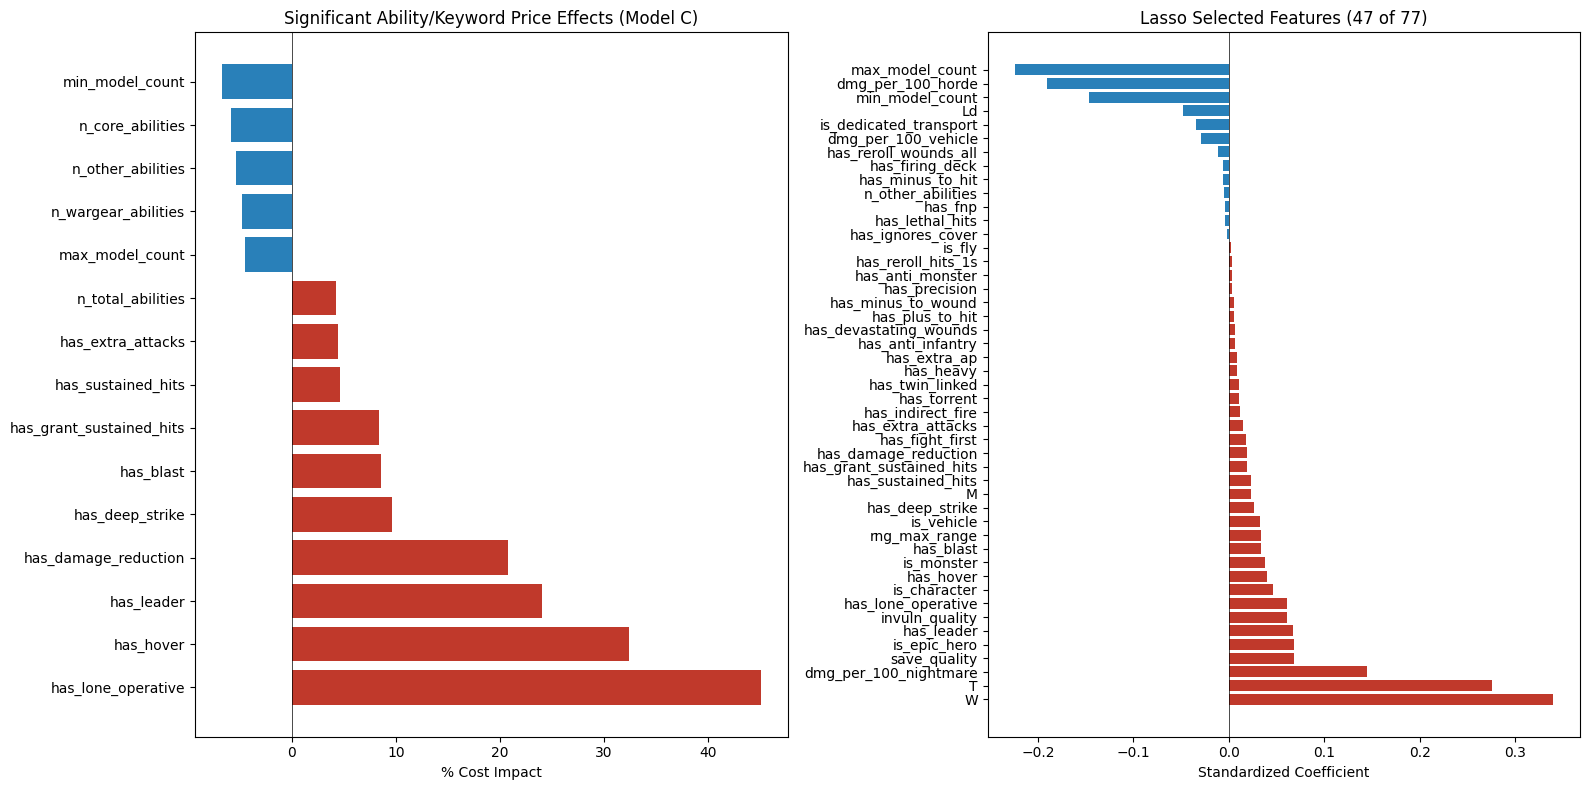

Saved ability_pricing.png


In [10]:
# --- Ability Pricing Analysis ---
# Show Model C coefficients (before faction effects) for ability features
# Express as % cost impact: (exp(coef) - 1) * 100

ability_related = (core_ability_cols + ability_count_cols + buff_cols_present + 
                   weapon_kw_cols + structural_cols)
ability_feats = [f for f in ability_related if f in model_C.params.index]

coef_df = pd.DataFrame({
    'feature': ability_feats,
    'coefficient': [model_C.params[f] for f in ability_feats],
    'pct_impact': [(np.exp(model_C.params[f]) - 1) * 100 for f in ability_feats],
    'p_value': [model_C.pvalues[f] for f in ability_feats],
    'significant': [model_C.pvalues[f] < 0.05 for f in ability_feats],
}).sort_values('pct_impact', ascending=False)

print("Ability/Keyword Feature Pricing (Model C, % cost impact per unit increase):")
print("=" * 80)
for _, row in coef_df.iterrows():
    sig = "***" if row['p_value'] < 0.001 else "** " if row['p_value'] < 0.01 else "*  " if row['p_value'] < 0.05 else "   "
    print(f"  {sig} {row['feature']:<35s} {row['pct_impact']:>+8.1f}%  (p={row['p_value']:.3f})")

# --- Lasso Feature Selection ---
all_feats = feats_C
X_lasso = StandardScaler().fit_transform(df.loc[idx_train, all_feats].astype(float))
y_lasso = y.loc[idx_train]

lasso = LassoCV(cv=5, random_state=42, max_iter=10000).fit(X_lasso, y_lasso)
lasso_coefs = pd.Series(lasso.coef_, index=all_feats)
selected = lasso_coefs[lasso_coefs.abs() > 0.001].sort_values(ascending=False)

print(f"\nLasso selected {len(selected)} features (alpha={lasso.alpha_:.4f}):")
print("-" * 60)
for feat, coef in selected.items():
    direction = "↑ cost" if coef > 0 else "↓ cost"
    print(f"  {feat:<35s} {coef:>+8.4f}  ({direction})")

# --- Visualization: Top ability coefficients ---
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Plot 1: Model C ability coefficients
sig_df = coef_df[coef_df['significant']].nlargest(20, 'pct_impact', keep='all')
if len(sig_df) < 20:
    sig_df = pd.concat([sig_df, coef_df[coef_df['significant']].nsmallest(20 - len(sig_df), 'pct_impact', keep='all')])
colors = ['#c0392b' if v > 0 else '#2980b9' for v in sig_df['pct_impact']]
axes[0].barh(sig_df['feature'], sig_df['pct_impact'], color=colors)
axes[0].set_xlabel('% Cost Impact')
axes[0].set_title('Significant Ability/Keyword Price Effects (Model C)')
axes[0].axvline(0, color='black', linewidth=0.5)

# Plot 2: Lasso selected features
if len(selected) > 0:
    colors2 = ['#c0392b' if v > 0 else '#2980b9' for v in selected]
    axes[1].barh(selected.index, selected.values, color=colors2)
    axes[1].set_xlabel('Standardized Coefficient')
    axes[1].set_title(f'Lasso Selected Features ({len(selected)} of {len(all_feats)})')
    axes[1].axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig(REPO / 'scripts' / 'ability_pricing.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved ability_pricing.png")

## Over/Undercosted Units by Faction

Using Model C (stats + abilities + buffs, no faction dummies) to predict what each unit
"should" cost based on its statline and abilities. The residual reveals what GW is
charging above or below the model's prediction — the faction-agnostic fair price.

Faction                   |                  Most OVERCOSTED                   |                  Most UNDERCOSTED                 
                          |          (paying more than stats suggest)          |             (bargain for what you get)            
adepta-sororitas          | Triumph of Saint Kathe (+63%, 235 vs 144ppm)       | Daemonifuge            (-47%, 42 vs 80ppm)        
adeptus-astartes          | Emperor’s Champion     (+81%, 100 vs 55ppm)        | Chaplain Grimaldus     (-51%, 28 vs 56ppm)        
adeptus-custodes          | Orion Assault Dropship (+42%, 690 vs 487ppm)       | Prosecutors            (-44%, 10 vs 18ppm)        
adeptus-mechanicus        | Kataphron Breachers    (+24%, 53 vs 43ppm)         | Cybernetica Datasmith  (-44%, 35 vs 63ppm)        
aeldari                   | D-cannon Platform      (+108%, 125 vs 60ppm)       | Ynnari Succubus        (-33%, 45 vs 68ppm)        
agents-of-the-imperium    | Vindicare Assassin     (+66%, 155 vs 93ppm)     

/var/folders/pc/dv67dcb90vg1ffg74g7gjvfc0000gn/T/ipykernel_39746/1278016090.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['predicted_log_ppm'] = model_C.predict(X_all)
/var/folders/pc/dv67dcb90vg1ffg74g7gjvfc0000gn/T/ipykernel_39746/1278016090.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['predicted_ppm'] = np.exp(df['predicted_log_ppm'])
/var/folders/pc/dv67dcb90vg1ffg74g7gjvfc0000gn/T/ipykernel_39746/1278016090.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `f

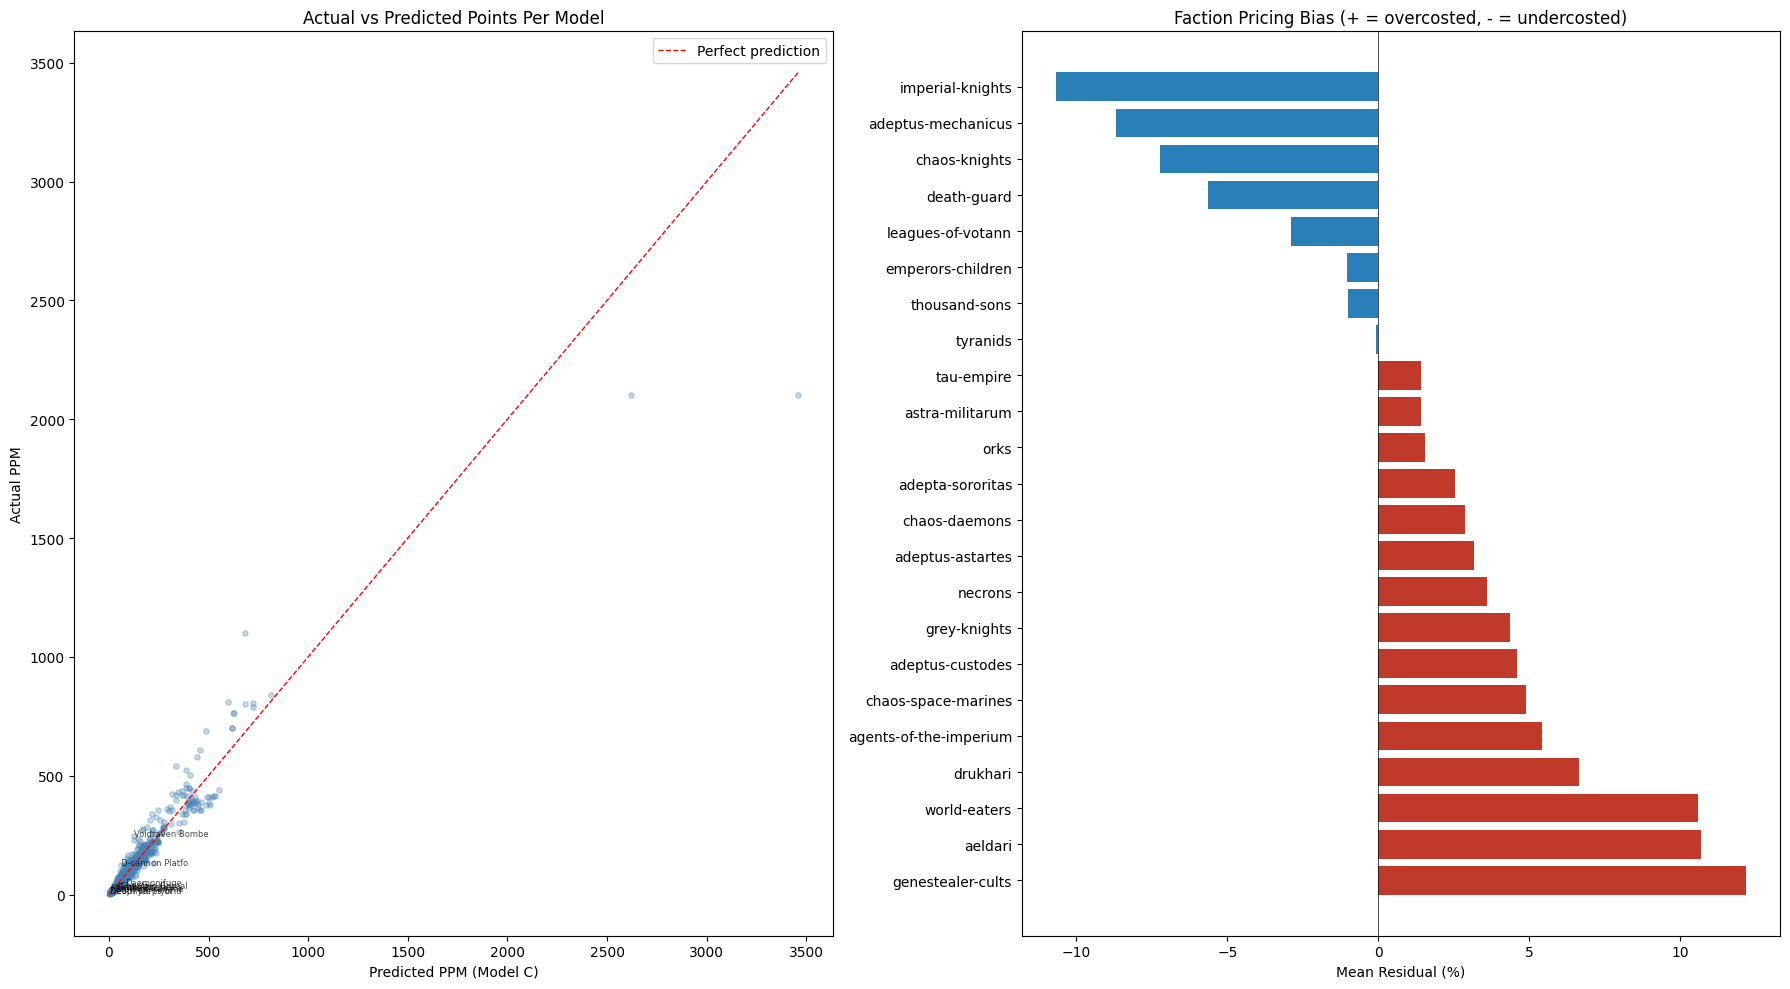

Saved over_undercosted.png


In [11]:
# Compute residuals from Model C (no faction effects)
# Predict for ALL units, not just train set
X_all = sm.add_constant(df[feats_C].astype(float))
df['predicted_log_ppm'] = model_C.predict(X_all)
df['predicted_ppm'] = np.exp(df['predicted_log_ppm'])
df['residual_pct'] = (df['ppm'] / df['predicted_ppm'] - 1) * 100  # +% = overcosted, -% = undercosted
df['residual_pts'] = df['ppm'] - df['predicted_ppm']  # absolute difference per model

# --- Most over/undercosted per faction ---
# Group by faction, show top 3 overcosted and top 3 undercosted
factions_sorted = sorted(df['faction'].unique())

print(f"{'Faction':<25s} | {'Most OVERCOSTED':^50s} | {'Most UNDERCOSTED':^50s}")
print(f"{'':<25s} | {'(paying more than stats suggest)':^50s} | {'(bargain for what you get)':^50s}")
print("=" * 130)

faction_summaries = []

for faction in factions_sorted:
    fdf = df[df['faction'] == faction].copy()
    if len(fdf) < 3:
        continue
    
    over = fdf.nlargest(1, 'residual_pct').iloc[0]
    under = fdf.nsmallest(1, 'residual_pct').iloc[0]
    
    over_str = f"{over['unit_name'][:22]:<22s} ({over['residual_pct']:+.0f}%, {over['ppm']:.0f} vs {over['predicted_ppm']:.0f}ppm)"
    under_str = f"{under['unit_name'][:22]:<22s} ({under['residual_pct']:+.0f}%, {under['ppm']:.0f} vs {under['predicted_ppm']:.0f}ppm)"
    
    print(f"{faction:<25s} | {over_str:<50s} | {under_str:<50s}")
    
    faction_summaries.append({
        'faction': faction,
        'n_units': len(fdf),
        'mean_residual_pct': fdf['residual_pct'].mean(),
        'overcosted_unit': over['unit_name'],
        'overcosted_pct': over['residual_pct'],
        'undercosted_unit': under['unit_name'],
        'undercosted_pct': under['residual_pct'],
    })

# --- Global top 15 over and undercosted ---
print("\n" + "=" * 100)
print("GLOBAL TOP 15 OVERCOSTED (paying the most above predicted value):")
print("-" * 100)
for _, row in df.nlargest(15, 'residual_pct').iterrows():
    print(f"  {row['unit_name']:<35s} {row['faction']:<22s} "
          f"actual={row['ppm']:>6.0f}ppm  predicted={row['predicted_ppm']:>6.0f}ppm  "
          f"delta={row['residual_pct']:>+6.1f}%")

print("\n" + "=" * 100)
print("GLOBAL TOP 15 UNDERCOSTED (biggest bargains relative to predicted value):")
print("-" * 100)
for _, row in df.nsmallest(15, 'residual_pct').iterrows():
    print(f"  {row['unit_name']:<35s} {row['faction']:<22s} "
          f"actual={row['ppm']:>6.0f}ppm  predicted={row['predicted_ppm']:>6.0f}ppm  "
          f"delta={row['residual_pct']:>+6.1f}%")

# --- Faction-level bias (is a whole faction over/undercosted?) ---
print("\n" + "=" * 100)
print("FACTION-LEVEL PRICING BIAS (mean residual across all units):")
print("-" * 100)
faction_bias = pd.DataFrame(faction_summaries).sort_values('mean_residual_pct', ascending=False)
for _, row in faction_bias.iterrows():
    bar = "+" * max(0, int(row['mean_residual_pct'] / 2)) + "-" * max(0, int(-row['mean_residual_pct'] / 2))
    print(f"  {row['faction']:<25s} {row['mean_residual_pct']:>+6.1f}%  ({row['n_units']:>3d} units)  {bar}")

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Plot 1: Actual vs Predicted PPM scatter
ax = axes[0]
ax.scatter(df['predicted_ppm'], df['ppm'], alpha=0.3, s=15, c='steelblue')
max_val = max(df['ppm'].max(), df['predicted_ppm'].max())
ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1, label='Perfect prediction')
ax.set_xlabel('Predicted PPM (Model C)')
ax.set_ylabel('Actual PPM')
ax.set_title('Actual vs Predicted Points Per Model')
ax.legend()
# Annotate biggest outliers
for _, row in df.nlargest(5, 'residual_pct').iterrows():
    ax.annotate(row['unit_name'][:15], (row['predicted_ppm'], row['ppm']),
                fontsize=6, alpha=0.7)
for _, row in df.nsmallest(5, 'residual_pct').iterrows():
    ax.annotate(row['unit_name'][:15], (row['predicted_ppm'], row['ppm']),
                fontsize=6, alpha=0.7)

# Plot 2: Faction bias bar chart
ax2 = axes[1]
colors = ['#c0392b' if v > 0 else '#2980b9' for v in faction_bias['mean_residual_pct']]
ax2.barh(faction_bias['faction'], faction_bias['mean_residual_pct'], color=colors)
ax2.set_xlabel('Mean Residual (%)')
ax2.set_title('Faction Pricing Bias (+ = overcosted, - = undercosted)')
ax2.axvline(0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig(REPO / 'scripts' / 'over_undercosted.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved over_undercosted.png")


## Maximum Damage Combo Search

For each of the 8 target templates, find the unit + buff stack that deals the most
damage per 100 points. Full stack: army rule + detachment rule + stratagem + leader + enhancement.

In [12]:
# --- Target Templates ---
TARGETS = [
    TargetProfile("20 Guardsmen", 20, T=3, W=1, Sv=5, keywords=['Infantry']),
    TargetProfile("10 Assault Intercessors", 10, T=4, W=2, Sv=3, keywords=['Infantry']),
    TargetProfile("5 Terminators", 5, T=5, W=3, Sv=2, invuln=4, keywords=['Infantry', 'Terminator']),
    TargetProfile("Rhino", 1, T=9, W=10, Sv=3, keywords=['Vehicle', 'Transport']),
    TargetProfile("Armiger Warglaive", 1, T=9, W=14, Sv=3, invuln=5, keywords=['Vehicle', 'Walker']),
    TargetProfile("Rogal Dorn", 1, T=12, W=18, Sv=2, keywords=['Vehicle']),
    TargetProfile("Knight Tyrant", 1, T=12, W=28, Sv=3, invuln=5, keywords=['Vehicle', 'Titanic', 'Walker']),
    TargetProfile("C'tan Nightbringer", 1, T=11, W=16, Sv=3, invuln=4, fnp=5,
                  damage_reduction=1, keywords=['Monster', 'Character']),
]

def compute_unit_total_damage(unit: dict, faction: str, target: TargetProfile,
                               buffs: Buffs = None, phase: str = 'shooting') -> float:
    """Compute total expected damage from a unit's weapons against a target.
    For ranged: fires all ranged weapons. For melee: fights with all melee weapons.
    Extra Attacks weapons are additive.
    """
    if buffs is None:
        buffs = Buffs()
    
    faction_weapons = weapon_lookup.get(faction, {})
    wtype = 'ranged' if phase == 'shooting' else 'melee'
    
    # Determine model count (minimum squad size)
    points = unit.get('points', [])
    if not points:
        return 0.0
    min_pts = min(points, key=lambda p: p.get('models', 999))
    n_models = min_pts.get('models', 1)
    
    total_damage = 0.0
    for wid in unit.get('weapon_ids', []):
        w = faction_weapons.get(wid)
        if not w or w.get('type') != wtype:
            continue
        for prof in w.get('profiles', []):
            stats = {**prof.get('stats', {}), 'keywords': prof.get('keywords', [])}
            result = expected_damage(stats, wtype, n_models, target, buffs)
            total_damage += result.get('wounds_inflicted', 0)
    
    return total_damage


def get_best_detachment_buffs(faction: str) -> tuple[str, list[str]]:
    """For a faction, find the detachment whose rule provides the best offensive buff.
    Returns (detachment_name, [description_texts])."""
    aa_code = FOURTYDC_TO_AA.get(faction, '')
    det_abilities = aa_det_abilities_lookup.get(aa_code, {})
    
    best_det = None
    best_score = -1
    best_descs = []
    
    for det_name, abilities in det_abilities.items():
        descs = [a.get('description', '') for a in abilities if a.get('description')]
        score = 0
        for desc in descs:
            extracted = extract_buffs_from_text(desc)
            if extracted.get('reroll_hits_all'): score += 5
            elif extracted.get('reroll_hits_1s'): score += 2
            if extracted.get('reroll_wounds_all'): score += 5
            elif extracted.get('reroll_wounds_1s'): score += 2
            if extracted.get('grant_lethal_hits'): score += 4
            if extracted.get('grant_sustained_hits'): score += 3
            if extracted.get('grant_devastating_wounds'): score += 3
            if extracted.get('plus_to_hit'): score += 3
            if extracted.get('plus_to_wound'): score += 3
            if extracted.get('extra_ap'): score += 2
            if extracted.get('extra_attacks'): score += 2
        
        if score > best_score:
            best_score = score
            best_det = det_name
            best_descs = descs
    
    return best_det or '', best_descs


def get_best_stratagem_buff(faction: str, detachment: str, phase: str) -> tuple[str, str]:
    """Find the best damage-boosting stratagem for a faction/detachment/phase.
    Returns (stratagem_name, description)."""
    aa_code = FOURTYDC_TO_AA.get(faction, '')
    strats = aa_strat_lookup.get(aa_code, {}).get(detachment, [])
    
    best_strat = None
    best_score = -1
    best_desc = ''
    
    for s in strats:
        # Filter by phase
        strat_phases = [p.lower() for p in s.get('phases', [])]
        if phase.lower() not in strat_phases and not any(phase.lower() in p for p in strat_phases):
            continue
        
        desc = s.get('description', '')
        extracted = extract_buffs_from_text(desc)
        score = 0
        if extracted.get('reroll_hits_all'): score += 5
        elif extracted.get('reroll_hits_1s'): score += 2
        if extracted.get('reroll_wounds_all'): score += 5
        elif extracted.get('reroll_wounds_1s'): score += 2
        if extracted.get('grant_lethal_hits'): score += 4
        if extracted.get('grant_sustained_hits'): score += 3
        if extracted.get('grant_devastating_wounds'): score += 3
        if extracted.get('plus_to_hit'): score += 3
        if extracted.get('plus_to_wound'): score += 3
        if extracted.get('extra_ap'): score += 2
        if extracted.get('extra_attacks'): score += 2
        if extracted.get('extra_strength'): score += 2
        
        if score > best_score:
            best_score = score
            best_strat = s.get('name', '')
            best_desc = desc
    
    return best_strat or '', best_desc


def get_best_leader_damage(unit: dict, faction: str, target: TargetProfile,
                            base_buffs: Buffs, phase: str) -> tuple[str, float, int]:
    """Find the leader that adds the most damage when attached.
    Returns (leader_id, additional_damage, leader_cost)."""
    leader_ids = bodyguard_leaders.get((faction, unit['id']), [])
    if not leader_ids:
        return '', 0.0, 0
    
    best_leader = ''
    best_extra_dmg = 0.0
    best_cost = 0
    
    for lid in leader_ids:
        leader = unit_lookup.get((faction, lid))
        if not leader:
            continue
        
        # Leader cost
        lpts = leader.get('points', [])
        if not lpts:
            continue
        lcost = min(p.get('cost', 999) for p in lpts)
        
        # Leader's own weapon damage
        leader_dmg = compute_unit_total_damage(leader, faction, target, base_buffs, phase)
        
        # Leader's ability buffs
        leader_abilities = unit_abilities.get((faction, lid), [])
        leader_descs = [a.get('description', '') for a in leader_abilities if a.get('description')]
        leader_buffs = text_to_buffs_object(leader_descs)
        
        # Merge leader buffs with base buffs (best of each)
        combined = Buffs(
            hit_mod=max(base_buffs.hit_mod, leader_buffs.hit_mod),
            wound_mod=max(base_buffs.wound_mod, leader_buffs.wound_mod),
            reroll_hits='all' if leader_buffs.reroll_hits == 'all' or base_buffs.reroll_hits == 'all'
                        else '1s' if leader_buffs.reroll_hits == '1s' or base_buffs.reroll_hits == '1s'
                        else 'none',
            reroll_wounds='all' if leader_buffs.reroll_wounds == 'all' or base_buffs.reroll_wounds == 'all'
                          else '1s' if leader_buffs.reroll_wounds == '1s' or base_buffs.reroll_wounds == '1s'
                          else 'none',
            reroll_damage=base_buffs.reroll_damage or leader_buffs.reroll_damage,
            extra_attacks=base_buffs.extra_attacks,  # leader attacks are separate
            extra_ap=max(base_buffs.extra_ap, leader_buffs.extra_ap),
            extra_strength=max(base_buffs.extra_strength, leader_buffs.extra_strength),
            grant_lethal_hits=base_buffs.grant_lethal_hits or leader_buffs.grant_lethal_hits,
            grant_sustained_hits=max(base_buffs.grant_sustained_hits, leader_buffs.grant_sustained_hits),
            grant_devastating_wounds=base_buffs.grant_devastating_wounds or leader_buffs.grant_devastating_wounds,
            grant_twin_linked=base_buffs.grant_twin_linked or leader_buffs.grant_twin_linked,
            assume_stationary=base_buffs.assume_stationary,
            assume_charged=base_buffs.assume_charged,
            assume_half_range=base_buffs.assume_half_range,
        )
        
        # Recompute unit damage with leader buffs + leader's own damage
        unit_dmg_with_buffs = compute_unit_total_damage(unit, faction, target, combined, phase)
        total_extra = unit_dmg_with_buffs + leader_dmg - compute_unit_total_damage(unit, faction, target, base_buffs, phase)
        
        # Efficiency: extra damage per extra cost
        if lcost > 0 and total_extra / lcost > best_extra_dmg / max(best_cost, 1):
            best_leader = lid
            best_extra_dmg = total_extra
            best_cost = lcost
    
    return best_leader, best_extra_dmg, best_cost

print("Combo search functions defined.")

Combo search functions defined.


In [13]:
# --- Run combo search for all targets ---
all_results = {}

for target in TARGETS:
    print(f"\n{'='*80}")
    print(f"TARGET: {target.name} (T{target.T}/W{target.W}/Sv{target.Sv}+"
          f"{f'/Inv{target.invuln}+' if target.invuln else ''}"
          f"{f'/FNP{target.fnp}+' if target.fnp else ''}"
          f"{f'/-{target.damage_reduction}D' if target.damage_reduction else ''})")
    print(f"{'='*80}")
    
    results = []
    for u in all_units:
        faction = u['_faction']
        points = u.get('points', [])
        if not points or not any(p.get('cost', 0) > 0 for p in points):
            continue
        
        min_pts = min(points, key=lambda p: p.get('models', 999))
        cost = min_pts.get('cost', 0)
        if cost <= 0:
            continue
        
        # Phase: use shooting for ranged, fight for melee. Compute both, take better.
        for phase in ['shooting', 'fight']:
            # Base damage (no buffs)
            base_buffs = Buffs(
                assume_stationary=(phase == 'shooting'),
                assume_charged=(phase == 'fight'),
                assume_half_range=True,
            )
            base_dmg = compute_unit_total_damage(u, faction, target, base_buffs, phase)
            if base_dmg <= 0:
                continue
            
            # Build buff stack
            buff_descs = []
            combo_parts = [u.get('name', u['id'])]
            
            # 1. Unit abilities
            unit_abs = unit_abilities.get((faction, u['id']), [])
            for ab in unit_abs:
                if ab.get('description'):
                    buff_descs.append(ab['description'])
            
            # 2. Army rule (faction abilities)
            aa_code = FOURTYDC_TO_AA.get(faction, '')
            faction_rules = aa_faction_rules.get(aa_code, [])
            for fr in faction_rules:
                if fr.get('description'):
                    buff_descs.append(fr['description'])
            
            # 3. Best detachment rule
            det_name, det_descs = get_best_detachment_buffs(faction)
            buff_descs.extend(det_descs)
            if det_name:
                combo_parts.append(f"det:{det_name}")
            
            # 4. Best stratagem
            strat_name, strat_desc = get_best_stratagem_buff(faction, det_name, phase.capitalize())
            if strat_desc:
                buff_descs.append(strat_desc)
                combo_parts.append(f"strat:{strat_name}")
            
            # Build buffs object
            full_buffs = text_to_buffs_object(buff_descs)
            full_buffs.assume_stationary = (phase == 'shooting')
            full_buffs.assume_charged = (phase == 'fight')
            full_buffs.assume_half_range = True
            
            buffed_dmg = compute_unit_total_damage(u, faction, target, full_buffs, phase)
            
            # 5. Leader
            leader_id, leader_extra, leader_cost = get_best_leader_damage(
                u, faction, target, full_buffs, phase
            )
            total_cost = cost + leader_cost
            total_dmg = buffed_dmg + leader_extra
            if leader_id:
                leader_unit = unit_lookup.get((faction, leader_id))
                if leader_unit:
                    combo_parts.append(f"leader:{leader_unit.get('name', leader_id)}")
            
            # Damage per 100 points
            dmg_per_100 = total_dmg / total_cost * 100
            
            results.append({
                'unit_name': u.get('name', u['id']),
                'faction': faction,
                'phase': phase,
                'cost': total_cost,
                'base_dmg': base_dmg,
                'buffed_dmg': total_dmg,
                'dmg_per_100': dmg_per_100,
                'combo': ' + '.join(combo_parts),
                'wounds_or_kills': total_dmg if target.models == 1 else total_dmg / target.W,
            })
    
    # Sort by damage per 100 points
    results.sort(key=lambda r: r['dmg_per_100'], reverse=True)
    all_results[target.name] = results
    
    # Print top 10
    print(f"\nTop 10 by damage per 100pts:")
    print(f"{'Rank':<5} {'Unit':<30} {'Faction':<20} {'Phase':<8} {'Cost':>5} "
          f"{'Base':>6} {'Buffed':>7} {'Dmg/100':>8} {'Kills/W':>8}")
    print("-" * 120)
    seen = set()
    rank = 0
    for r in results:
        key = (r['unit_name'], r['faction'])
        if key in seen:
            continue
        seen.add(key)
        rank += 1
        if rank > 10:
            break
        metric = f"{r['wounds_or_kills']:.1f}k" if target.models > 1 else f"{r['wounds_or_kills']:.1f}w"
        print(f"{rank:<5} {r['unit_name']:<30} {r['faction']:<20} {r['phase']:<8} "
              f"{r['cost']:>5} {r['base_dmg']:>6.1f} {r['buffed_dmg']:>7.1f} "
              f"{r['dmg_per_100']:>8.2f} {metric:>8}")
    
    # Print best combo breakdown
    if results:
        best = results[0]
        print(f"\n  Best combo: {best['combo']}")

print(f"\n{'='*80}")
print("Combo search complete.")


TARGET: 20 Guardsmen (T3/W1/Sv5+)



Top 10 by damage per 100pts:
Rank  Unit                           Faction              Phase     Cost   Base  Buffed  Dmg/100  Kills/W
------------------------------------------------------------------------------------------------------------------------
1     Death Korps of Krieg           astra-militarum      shooting   105   99.4   196.6   187.21   196.6k
2     Tactical Squad                 adeptus-astartes     shooting   215  208.8   331.3   154.07   331.3k
3     Sisters of Battle Squad        agents-of-the-imperium shooting   155  134.6   214.4   138.35   214.4k
4     Battle Sisters Squad           adepta-sororitas     shooting   155  138.4   210.0   135.50   210.0k
5     Servitor Battleclade           adeptus-mechanicus   shooting    60   49.0    81.2   135.42    81.2k
6     Cadian Shock Troops            astra-militarum      shooting   105   77.2   139.2   132.61   139.2k
7     Kasrkin                        astra-militarum      shooting   150  114.3   197.5   131.65   197.5k


Top 10 by damage per 100pts:
Rank  Unit                           Faction              Phase     Cost   Base  Buffed  Dmg/100  Kills/W
------------------------------------------------------------------------------------------------------------------------
1     Death Korps of Krieg           astra-militarum      shooting   130   80.2   217.1   166.98   108.5k
2     Tactical Squad                 adeptus-astartes     shooting   215  180.2   321.7   149.65   160.9k
3     Sisters of Battle Squad        agents-of-the-imperium shooting   155  119.0   198.8   128.29    99.4k
4     Kasrkin                        astra-militarum      shooting   150   88.0   186.7   124.47    93.3k
5     Servitor Battleclade           adeptus-mechanicus   shooting    60   49.4    74.1   123.54    37.1k
6     Battle Sisters Squad           adepta-sororitas     shooting   155  124.4   183.0   118.05    91.5k
7     Tempestus Aquilons             astra-militarum      shooting   100   83.1   117.2   117.18    58.6k


Top 10 by damage per 100pts:
Rank  Unit                           Faction              Phase     Cost   Base  Buffed  Dmg/100  Kills/W
------------------------------------------------------------------------------------------------------------------------
1     Tactical Squad                 adeptus-astartes     shooting   220  104.7   225.2   102.35    75.1k
2     Death Korps of Krieg           astra-militarum      shooting   105   35.8   103.8    98.88    34.6k
3     Sisters of Battle Squad        agents-of-the-imperium shooting   155   63.7   143.8    92.75    47.9k
4     Helbrute                       thousand-sons        shooting   110    9.6   100.9    91.72    33.6k
5     Servitor Battleclade           adeptus-mechanicus   shooting    60   28.9    51.8    86.25    17.2k
6     Helbrute                       world-eaters         shooting   120   10.4    96.2    80.15    32.1k
7     Kasrkin                        astra-militarum      shooting   150   42.1   116.6    77.73    38.9k


Top 10 by damage per 100pts:
Rank  Unit                           Faction              Phase     Cost   Base  Buffed  Dmg/100  Kills/W
------------------------------------------------------------------------------------------------------------------------
1     Death Korps of Krieg           astra-militarum      shooting   130   38.4   137.7   105.90   137.7w
2     Tactical Squad                 adeptus-astartes     shooting   220  101.5   181.4    82.45   181.4w
3     Sisters of Battle Squad        agents-of-the-imperium shooting   155   62.6   115.1    74.27   115.1w
4     Helbrute                       thousand-sons        shooting   110   12.8    77.4    70.33    77.4w
5     Kasrkin                        astra-militarum      shooting   150   42.2   104.8    69.87   104.8w
6     Tempestus Aquilons             astra-militarum      shooting   100   40.1    69.6    69.58    69.6w
7     Catachan Command Squad         astra-militarum      shooting    65   26.5    43.0    66.20    43.0w


Top 10 by damage per 100pts:
Rank  Unit                           Faction              Phase     Cost   Base  Buffed  Dmg/100  Kills/W
------------------------------------------------------------------------------------------------------------------------
1     Death Korps of Krieg           astra-militarum      shooting   130   38.1   135.1   103.96   135.1w
2     Tactical Squad                 adeptus-astartes     shooting   220  111.3   222.7   101.23   222.7w
3     Helbrute                       thousand-sons        shooting   110   10.9    99.9    90.82    99.9w
4     Sisters of Battle Squad        agents-of-the-imperium shooting   155   65.1   136.7    88.17   136.7w
5     Servitor Battleclade           adeptus-mechanicus   shooting    60   33.1    49.5    82.43    49.5w
6     Jakhals                        world-eaters         fight       65   18.4    52.2    80.30    52.2w
7     Helbrute                       world-eaters         shooting   120   12.9    95.6    79.65    95.6w


Top 10 by damage per 100pts:
Rank  Unit                           Faction              Phase     Cost   Base  Buffed  Dmg/100  Kills/W
------------------------------------------------------------------------------------------------------------------------
1     Tactical Squad                 adeptus-astartes     shooting   220   94.3   243.7   110.76   243.7w
2     Death Korps of Krieg           astra-militarum      shooting   130   30.0   139.1   106.99   139.1w
3     Helbrute                       thousand-sons        shooting   110    7.3   111.0   100.94   111.0w
4     Sisters of Battle Squad        agents-of-the-imperium shooting   155   54.8   142.4    91.90   142.4w
5     Helbrute                       world-eaters         shooting   120    8.6   103.1    85.88   103.1w
6     Servitor Battleclade           adeptus-mechanicus   shooting    60   25.0    49.8    82.92    49.8w
7     Jakhals                        world-eaters         fight       65   20.8    52.3    80.40    52.3w


Top 10 by damage per 100pts:
Rank  Unit                           Faction              Phase     Cost   Base  Buffed  Dmg/100  Kills/W
------------------------------------------------------------------------------------------------------------------------
1     Tactical Squad                 adeptus-astartes     shooting   225  114.5   312.3   138.78   312.3w
2     Sisters of Battle Squad        agents-of-the-imperium shooting   155   57.2   181.2   116.88   181.2w
3     Death Korps of Krieg           astra-militarum      shooting   105   32.5   122.5   116.65   122.5w
4     Helbrute                       thousand-sons        shooting   110    7.9   125.3   113.89   125.3w
5     Helbrute                       world-eaters         shooting   120    9.5   134.2   111.83   134.2w
6     Imperial Navy Breachers        agents-of-the-imperium shooting   130   26.8   142.8   109.88   142.8w
7     Jakhals                        world-eaters         fight       65   28.1    70.9   109.15    70.


Top 10 by damage per 100pts:
Rank  Unit                           Faction              Phase     Cost   Base  Buffed  Dmg/100  Kills/W
------------------------------------------------------------------------------------------------------------------------
1     Tactical Squad                 adeptus-astartes     shooting   225   38.6   139.8    62.15   139.8w
2     Sisters of Battle Squad        agents-of-the-imperium shooting   155   26.3    88.0    56.79    88.0w
3     Imperial Navy Breachers        agents-of-the-imperium shooting   130   10.6    71.8    55.20    71.8w
4     Jakhals                        world-eaters         fight       65    7.8    33.9    52.21    33.9w
5     Helbrute                       world-eaters         shooting   120    4.0    61.6    51.32    61.6w
6     Fortis Kill Team               adeptus-astartes     shooting   245   47.9   125.0    51.01   125.0w
7     Helbrute                       thousand-sons        shooting   110    3.0    55.1    50.12    55.

OVERCOSTED UNITS — DO THEY DELIVER DAMAGE?
Unit                           Faction               Resid%  AvgDmg/100  vs Horde  vs Elite vs Vehicle  vs C'tan Verdict             
--------------------------------------------------------------------------------------------------------------------------------------------
D-cannon Platform              aeldari                +108%         3.1       3.3       2.5        3.0       1.4 GENUINELY OVERCOSTED
Death Korps of Krieg           astra-militarum        +105%        70.6     153.0      55.1       58.5      19.3 EFFICIENT (model is blind)
Voidraven Bomber               drukhari                +93%         3.2       4.6       2.6        2.8       1.0 GENUINELY OVERCOSTED
Neophyte Hybrids               genestealer-cults       +91%        53.6     126.1      41.4       48.0      18.8 EFFICIENT (model is blind)
Khorne Berzerkers              world-eaters            +89%         6.9      13.0       6.3        5.9       1.9 EFFICIENT (model is b

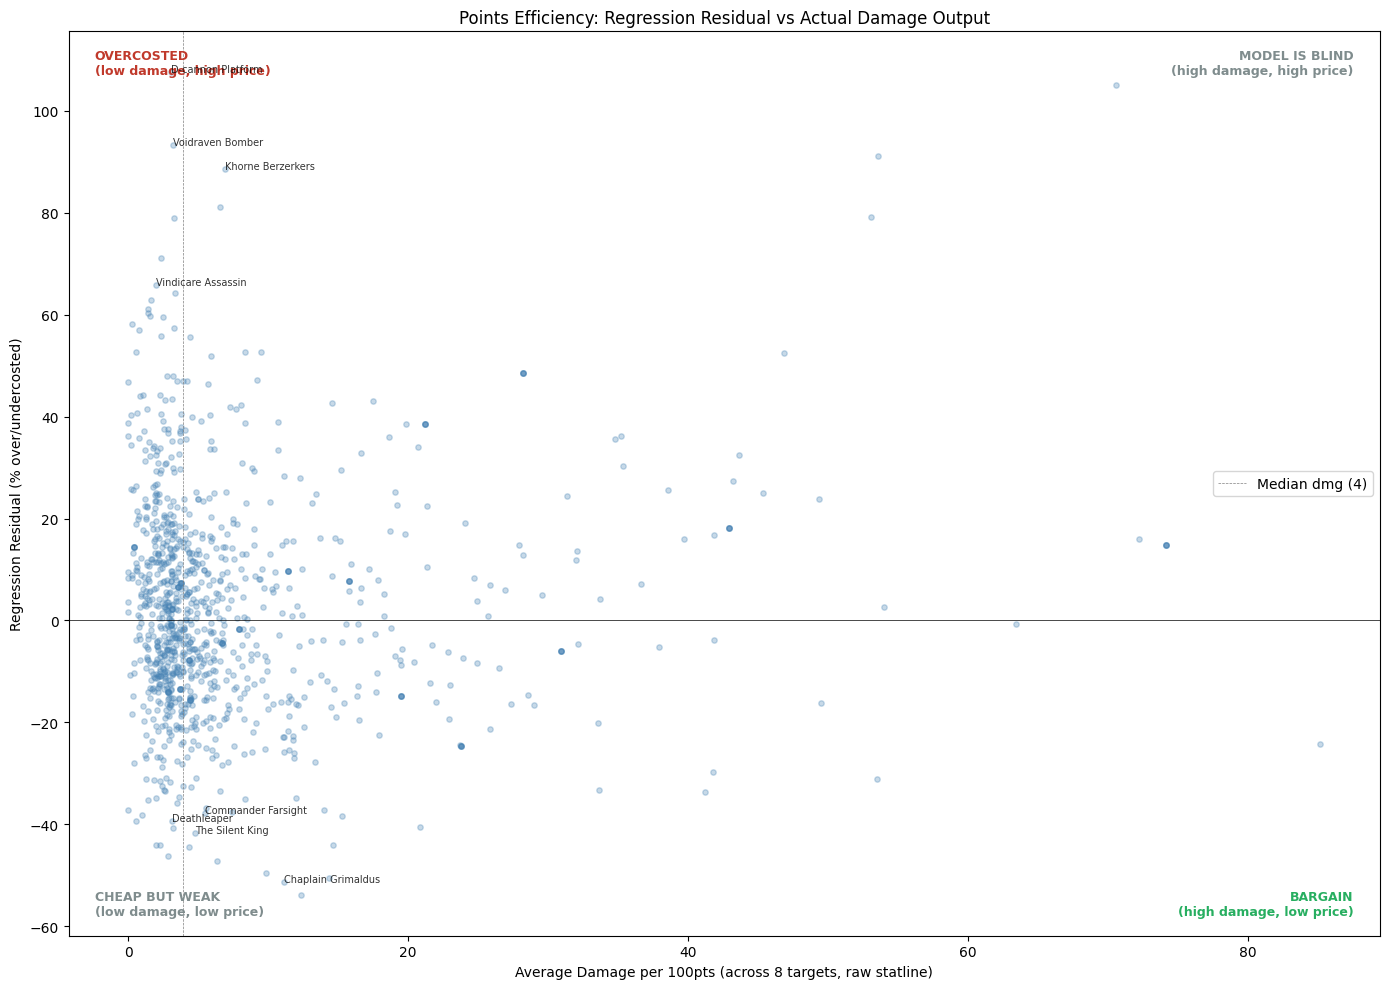

Saved residual_vs_damage.png


In [14]:
# --- Cross-reference: residual vs actual damage efficiency ---
# For every unit, compute average damage per 100pts across all 8 targets (shooting + melee best)
# This reveals whether "overcosted" units actually deliver damage or are genuinely overpriced.

unit_damage_efficiency = []

for u in all_units:
    faction = u['_faction']
    points = u.get('points', [])
    if not points or not any(p.get('cost', 0) > 0 for p in points):
        continue
    min_pts = min(points, key=lambda p: p.get('models', 999))
    cost = min_pts.get('cost', 0)
    if cost <= 0:
        continue
    
    # Compute damage into each target (no buffs — raw statline only)
    target_damages = []
    for target in TARGETS:
        best_phase_dmg = 0
        for phase in ['shooting', 'fight']:
            buffs = Buffs(
                assume_stationary=(phase == 'shooting'),
                assume_charged=(phase == 'fight'),
                assume_half_range=True,
            )
            dmg = compute_unit_total_damage(u, faction, target, buffs, phase)
            best_phase_dmg = max(best_phase_dmg, dmg)
        target_damages.append(best_phase_dmg)
    
    avg_dmg = np.mean(target_damages)
    avg_dmg_per_100 = avg_dmg / cost * 100
    
    unit_damage_efficiency.append({
        'unit_id': u['id'],
        'unit_name': u.get('name', ''),
        'faction': faction,
        'cost': cost,
        'avg_dmg_per_100': avg_dmg_per_100,
        'avg_raw_dmg': avg_dmg,
        'dmg_vs_horde': target_damages[0] / cost * 100,  # guardsmen
        'dmg_vs_elite': target_damages[2] / cost * 100,   # terminators
        'dmg_vs_vehicle': target_damages[4] / cost * 100,  # armiger
        'dmg_vs_nightmare': target_damages[7] / cost * 100,  # nightbringer
    })

dmg_df = pd.DataFrame(unit_damage_efficiency)

# Merge with residuals from df
merge_df = df[['unit_id', 'faction', 'residual_pct', 'ppm', 'predicted_ppm']].copy()
combined = dmg_df.merge(merge_df, on=['unit_id', 'faction'], how='inner')

# --- Print the overcosted units WITH their damage efficiency ---
print("OVERCOSTED UNITS — DO THEY DELIVER DAMAGE?")
print("=" * 140)
print(f"{'Unit':<30s} {'Faction':<20s} {'Resid%':>7s} {'AvgDmg/100':>11s} "
      f"{'vs Horde':>9s} {'vs Elite':>9s} {'vs Vehicle':>10s} {'vs C\'tan':>9s} {'Verdict':<20s}")
print("-" * 140)

# Get the top 20 overcosted
overcosted = combined.nlargest(20, 'residual_pct')
# Also get the median damage efficiency as reference
median_dmg = combined['avg_dmg_per_100'].median()

for _, row in overcosted.iterrows():
    verdict = "EFFICIENT (model is blind)" if row['avg_dmg_per_100'] > median_dmg else "GENUINELY OVERCOSTED"
    print(f"{row['unit_name']:<30s} {row['faction']:<20s} {row['residual_pct']:>+6.0f}% "
          f"{row['avg_dmg_per_100']:>11.1f} "
          f"{row['dmg_vs_horde']:>9.1f} {row['dmg_vs_elite']:>9.1f} "
          f"{row['dmg_vs_vehicle']:>10.1f} {row['dmg_vs_nightmare']:>9.1f} {verdict:<20s}")

print(f"\nMedian damage/100pts across all units: {median_dmg:.1f}")
print(f"Units above median are delivering real damage — the model just can't see it.")

# --- Print the GENUINELY overcosted (high residual + LOW damage) ---
print("\n" + "=" * 140)
print("GENUINELY OVERCOSTED: high residual AND below-median damage output")
print("-" * 140)
genuine_over = combined[(combined['residual_pct'] > 20) & (combined['avg_dmg_per_100'] < median_dmg)]
genuine_over = genuine_over.sort_values('residual_pct', ascending=False)
for _, row in genuine_over.head(20).iterrows():
    print(f"  {row['unit_name']:<30s} {row['faction']:<20s} resid={row['residual_pct']:>+6.0f}%  "
          f"dmg/100={row['avg_dmg_per_100']:>6.1f} (median={median_dmg:.1f})")

# --- And the GENUINELY undercosted (low residual + HIGH damage) ---
print("\n" + "=" * 140)
print("GENUINELY UNDERCOSTED: low residual AND above-median damage output")
print("-" * 140)
genuine_under = combined[(combined['residual_pct'] < -20) & (combined['avg_dmg_per_100'] > median_dmg)]
genuine_under = genuine_under.sort_values('residual_pct')
for _, row in genuine_under.head(20).iterrows():
    print(f"  {row['unit_name']:<30s} {row['faction']:<20s} resid={row['residual_pct']:>+6.0f}%  "
          f"dmg/100={row['avg_dmg_per_100']:>6.1f} (median={median_dmg:.1f})")

# --- Scatter: residual vs damage efficiency ---
fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(combined['avg_dmg_per_100'], combined['residual_pct'], alpha=0.3, s=15, c='steelblue')
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(median_dmg, color='gray', linewidth=0.5, linestyle='--', label=f'Median dmg ({median_dmg:.0f})')
ax.set_xlabel('Average Damage per 100pts (across 8 targets, raw statline)')
ax.set_ylabel('Regression Residual (% over/undercosted)')
ax.set_title('Points Efficiency: Regression Residual vs Actual Damage Output')

# Quadrant labels
ax.text(0.02, 0.98, 'OVERCOSTED\n(low damage, high price)', transform=ax.transAxes,
        va='top', ha='left', fontsize=9, color='#c0392b', weight='bold')
ax.text(0.98, 0.98, 'MODEL IS BLIND\n(high damage, high price)', transform=ax.transAxes,
        va='top', ha='right', fontsize=9, color='#7f8c8d', weight='bold')
ax.text(0.02, 0.02, 'CHEAP BUT WEAK\n(low damage, low price)', transform=ax.transAxes,
        va='bottom', ha='left', fontsize=9, color='#7f8c8d', weight='bold')
ax.text(0.98, 0.02, 'BARGAIN\n(high damage, low price)', transform=ax.transAxes,
        va='bottom', ha='right', fontsize=9, color='#27ae60', weight='bold')

# Annotate notable units
notable = [
    'Khorne Berzerkers', 'Voidraven Bomber', 'D-cannon Platform',
    "Emperor\'s Champion", 'Vindicare Assassin', 'The Silent King',
    'Deathleaper', 'Commander Farsight', 'Chaplain Grimaldus',
]
for _, row in combined.iterrows():
    if any(n.replace("\\'", "\'") in row['unit_name'] for n in notable):
        ax.annotate(row['unit_name'][:20], (row['avg_dmg_per_100'], row['residual_pct']),
                    fontsize=7, alpha=0.8)

ax.legend()
plt.tight_layout()
plt.savefig(REPO / 'scripts' / 'residual_vs_damage.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved residual_vs_damage.png")


## Deep Dive: Ability Mechanics and Unit Pricing

With structured DSL data covering every damage-relevant ability in the game,
we can now decompose exactly how GW prices individual mechanics — rerolls,
keyword grants, stat modifiers, and their interactions.

In [15]:
# === REROLL PRICING ===
# How much does each type of reroll add to a unit's cost?
# Compare: reroll-all-hits vs reroll-1s-hits vs reroll-wounds vs reroll-damage

# Extract reroll features from DSL data for each unit
reroll_features = []
for u in all_units:
    faction = u['_faction']
    uid = u['id']
    points = u.get('points', [])
    if not points: continue
    min_pts = min(points, key=lambda p: p.get('models', 999))
    cost = min_pts.get('cost', 0)
    n_models = min_pts.get('models', 1)
    if cost <= 0 or n_models <= 0: continue
    
    # Get DSL buffs
    b = dsl_to_buffs(faction, uid, 'shooting')
    b_melee = dsl_to_buffs(faction, uid, 'fight')
    
    reroll_features.append({
        'unit_name': u.get('name', ''),
        'faction': faction,
        'ppm': cost / n_models,
        'rr_hits_all': b.reroll_hits == 'all' or b_melee.reroll_hits == 'all',
        'rr_hits_1s': b.reroll_hits == '1s' or b_melee.reroll_hits == '1s',
        'rr_wounds_all': b.reroll_wounds == 'all' or b_melee.reroll_wounds == 'all',
        'rr_wounds_1s': b.reroll_wounds == '1s' or b_melee.reroll_wounds == '1s',
        'rr_damage': b.reroll_damage or b_melee.reroll_damage,
        'grant_lethal': b.grant_lethal_hits or b_melee.grant_lethal_hits,
        'grant_sustained': max(b.grant_sustained_hits, b_melee.grant_sustained_hits),
        'grant_dw': b.grant_devastating_wounds or b_melee.grant_devastating_wounds,
        'extra_attacks': max(b.extra_attacks, b_melee.extra_attacks),
        'extra_strength': max(b.extra_strength, b_melee.extra_strength),
        'extra_ap': max(b.extra_ap, b_melee.extra_ap),
        'hit_mod': max(b.hit_mod, b_melee.hit_mod),
        'wound_mod': max(b.wound_mod, b_melee.wound_mod),
    })

rr_df = pd.DataFrame(reroll_features)

# Merge with regression residuals from Model C
rr_df = rr_df.merge(
    df[['unit_name', 'faction', 'ppm', 'log_ppm', 'predicted_ppm', 'residual_pct',
        'T', 'W', 'save_quality']].rename(columns={'ppm': 'ppm_reg'}),
    on=['unit_name', 'faction'], how='inner'
)

print("=== REROLL VALUE ANALYSIS ===")
print(f"Units with reroll all hits:    {rr_df['rr_hits_all'].sum():>4d}  "
      f"median PPM: {rr_df[rr_df['rr_hits_all']]['ppm'].median():>6.0f}  "
      f"vs no-reroll: {rr_df[~rr_df['rr_hits_all'] & ~rr_df['rr_hits_1s']]['ppm'].median():>6.0f}")
print(f"Units with reroll 1s hits:     {rr_df['rr_hits_1s'].sum():>4d}  "
      f"median PPM: {rr_df[rr_df['rr_hits_1s']]['ppm'].median():>6.0f}")
print(f"Units with reroll all wounds:  {rr_df['rr_wounds_all'].sum():>4d}  "
      f"median PPM: {rr_df[rr_df['rr_wounds_all']]['ppm'].median():>6.0f}")
print(f"Units with reroll 1s wounds:   {rr_df['rr_wounds_1s'].sum():>4d}  "
      f"median PPM: {rr_df[rr_df['rr_wounds_1s']]['ppm'].median():>6.0f}")
print(f"Units with reroll damage:      {rr_df['rr_damage'].sum():>4d}  "
      f"median PPM: {rr_df[rr_df['rr_damage']]['ppm'].median():>6.0f}")

# Mean residual by reroll type (controlling for stats via Model C residual)
print("\n=== REROLL PREMIUM (Model C residual — what GW charges ABOVE stat prediction) ===")
mechanics = [
    ('Reroll ALL hits', 'rr_hits_all'),
    ('Reroll 1s hits', 'rr_hits_1s'),
    ('Reroll ALL wounds', 'rr_wounds_all'),
    ('Reroll 1s wounds', 'rr_wounds_1s'),
    ('Reroll damage', 'rr_damage'),
    ('Lethal Hits (ability)', 'grant_lethal'),
    ('Devastating Wounds (ability)', 'grant_dw'),
    ('+1 to hit', lambda df: df['hit_mod'] >= 1),
    ('+1 to wound', lambda df: df['wound_mod'] >= 1),
    ('Extra attacks (any)', lambda df: df['extra_attacks'] > 0),
    ('Extra AP', lambda df: df['extra_ap'] > 0),
    ('Extra strength', lambda df: df['extra_strength'] > 0),
    ('Sustained Hits (ability)', lambda df: df['grant_sustained'] > 0),
]

print(f"{'Mechanic':<30s} {'Count':>6s} {'Mean Residual%':>15s} {'Median PPM':>11s} {'vs Baseline':>12s}")
print("-" * 80)
baseline_ppm = rr_df['ppm'].median()
for name, col in mechanics:
    if callable(col):
        mask = col(rr_df)
    else:
        mask = rr_df[col]
    count = mask.sum()
    if count < 3:
        continue
    mean_resid = rr_df.loc[mask, 'residual_pct'].mean()
    med_ppm = rr_df.loc[mask, 'ppm'].median()
    print(f"{name:<30s} {count:>6d} {mean_resid:>+14.1f}% {med_ppm:>11.0f} {med_ppm/baseline_ppm:>11.1f}x")


=== REROLL VALUE ANALYSIS ===
Units with reroll all hits:     279  median PPM:     75  vs no-reroll:     75
Units with reroll 1s hits:       60  median PPM:     65
Units with reroll all wounds:   276  median PPM:     75
Units with reroll 1s wounds:     26  median PPM:     21
Units with reroll damage:        16  median PPM:    140

=== REROLL PREMIUM (Model C residual — what GW charges ABOVE stat prediction) ===
Mechanic                        Count  Mean Residual%  Median PPM  vs Baseline
--------------------------------------------------------------------------------
Reroll ALL hits                   279           +3.0%          75         1.0x
Reroll 1s hits                     60           -0.4%          65         0.9x
Reroll ALL wounds                 276           +3.0%          75         1.0x
Reroll 1s wounds                   26           +2.0%          21         0.3x
Reroll damage                      16           +9.2%         140         1.9x
Lethal Hits (ability)         

In [16]:
# === WEAPON KEYWORD PRICING ===
# How much does each weapon keyword add to unit cost?
# Use Model C residuals to control for stats — the residual shows what GW charges
# above/below the prediction from stats+abilities.

keyword_features = [
    ('Torrent', 'has_torrent'),
    ('Blast', 'has_blast'),
    ('Lethal Hits (weapon)', 'has_lethal_hits'),
    ('Sustained Hits (weapon)', 'has_sustained_hits'),
    ('Devastating Wounds (weapon)', 'has_devastating_wounds'),
    ('Twin-linked', 'has_twin_linked'),
    ('Melta', 'has_melta'),
    ('Lance', 'has_lance'),
    ('Heavy', 'has_heavy'),
    ('Indirect Fire', 'has_indirect_fire'),
    ('Precision', 'has_precision'),
    ('Anti-Infantry', 'has_anti_infantry'),
    ('Anti-Vehicle', 'has_anti_vehicle'),
    ('Anti-Monster', 'has_anti_monster'),
]

print("=== WEAPON KEYWORD PRICING (from Model C coefficients) ===")
print(f"{'Keyword':<30s} {'Coef (log)':>10s} {'% Cost':>10s} {'p-value':>10s} {'Sig':>5s} {'Units with':>10s}")
print("-" * 80)

for name, col in keyword_features:
    if col in model_C.params.index:
        coef = model_C.params[col]
        pct = (np.exp(coef) - 1) * 100
        pval = model_C.pvalues[col]
        sig = "***" if pval < 0.001 else "**" if pval < 0.01 else "*" if pval < 0.05 else ""
        count = int(df[col].sum()) if col in df.columns else 0
        print(f"{name:<30s} {coef:>+10.4f} {pct:>+9.1f}% {pval:>10.3f} {sig:>5s} {count:>10d}")

# Interaction analysis: which keyword COMBINATIONS are most valuable?
print("\n=== KEYWORD COMBINATIONS (top 10 by frequency) ===")
kw_cols = [col for _, col in keyword_features if col in df.columns]
combo_counts = df[kw_cols].apply(lambda row: tuple(c for c in kw_cols if row[c]), axis=1)
combo_freq = combo_counts.value_counts().head(15)
print(f"{'Combination':<60s} {'Count':>6s} {'Median PPM':>10s}")
print("-" * 80)
for combo, count in combo_freq.items():
    if not combo or count < 5:
        continue
    mask = pd.Series(True, index=df.index)
    for c in combo:
        mask &= df[c] == 1
    combo_name = ' + '.join(c.replace('has_', '').replace('_', ' ').title() for c in combo)
    if len(combo_name) > 58:
        combo_name = combo_name[:55] + '...'
    med = df.loc[mask, 'ppm'].median()
    print(f"{combo_name:<60s} {count:>6d} {med:>10.0f}")


=== WEAPON KEYWORD PRICING (from Model C coefficients) ===
Keyword                        Coef (log)     % Cost    p-value   Sig Units with
--------------------------------------------------------------------------------
Torrent                           +0.0395      +4.0%      0.059              269
Blast                             +0.0822      +8.6%      0.001   ***        297
Lethal Hits (weapon)              -0.0361      -3.5%      0.139              149
Sustained Hits (weapon)           +0.0453      +4.6%      0.026     *        296
Devastating Wounds (weapon)       +0.0238      +2.4%      0.269              308
Twin-linked                       +0.0188      +1.9%      0.361              243
Melta                             +0.0112      +1.1%      0.660              142
Lance                             +0.0522      +5.4%      0.304               34
Heavy                             +0.0418      +4.3%      0.158              148
Indirect Fire                     +0.0427      +4.

=== DAMAGE IMPROVEMENT BY TARGET (% better than units without this mechanic) ===
Mechanic                         vs Horde   vs Elite vs Vehicle   vs C'tan
---------------------------------------------------------------------------
Reroll ALL hits                      +46%       +45%       +74%       +68%
Reroll 1s hits                        -3%       -20%       -19%        -9%
Reroll ALL wounds                    +41%       +43%       +73%       +66%
Reroll 1s wounds                     +15%        +5%       +30%       +29%
Reroll damage                        -33%       -38%       -41%       -45%
Lethal Hits (ability)                 +4%        -9%       -18%       -16%
Devastating Wounds (ability)         -16%       -20%        -7%        +1%
+1 to hit                             -7%        -7%       -12%        -7%
+1 to wound                          +48%       +45%       +63%       +67%
Extra attacks (any)                   -1%        +2%        +5%        -2%
Extra AP          

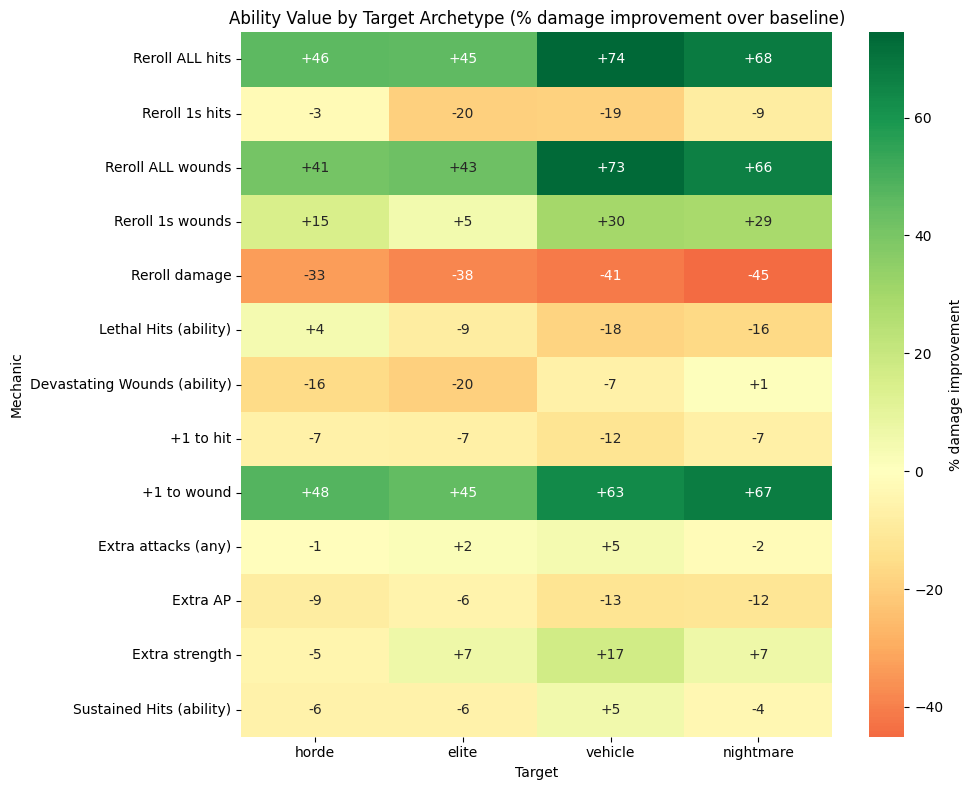

Saved buff_heatmap.png


In [17]:
# === ABILITY VALUE BY TARGET ARCHETYPE ===
# How much does each buff type improve damage output against each target?
# This reveals which abilities are "horde killers" vs "tank busters"

# For each buff type, compute the average damage improvement it provides
# by comparing units WITH the buff to units WITHOUT (controlling for cost)

buff_impact = []
for buff_name, buff_col_or_fn in mechanics:
    if callable(buff_col_or_fn):
        mask = buff_col_or_fn(rr_df)
    else:
        mask = rr_df[buff_col_or_fn]
    
    count = mask.sum()
    if count < 5:
        continue
    
    # Get damage features for units with/without this buff
    with_buff = df[df.index.isin(rr_df[mask].index)]
    without_buff = df[df.index.isin(rr_df[~mask].index)]
    
    if len(with_buff) < 3 or len(without_buff) < 3:
        continue
    
    row = {'Mechanic': buff_name, 'Count': int(count)}
    for target_col in ['dmg_per_100_horde', 'dmg_per_100_elite', 'dmg_per_100_vehicle', 'dmg_per_100_nightmare']:
        if target_col in df.columns:
            with_med = with_buff[target_col].median()
            without_med = without_buff[target_col].median()
            improvement = (with_med / max(without_med, 0.01) - 1) * 100
            row[target_col.replace('dmg_per_100_', '')] = improvement
    buff_impact.append(row)

impact_df = pd.DataFrame(buff_impact)
print("=== DAMAGE IMPROVEMENT BY TARGET (% better than units without this mechanic) ===")
print(f"{'Mechanic':<30s} {'vs Horde':>10s} {'vs Elite':>10s} {'vs Vehicle':>10s} {'vs C\'tan':>10s}")
print("-" * 75)
for _, row in impact_df.iterrows():
    print(f"{row['Mechanic']:<30s} "
          f"{row.get('horde', 0):>+9.0f}% "
          f"{row.get('elite', 0):>+9.0f}% "
          f"{row.get('vehicle', 0):>+9.0f}% "
          f"{row.get('nightmare', 0):>+9.0f}%")

# Visualization: heatmap of buff value by target
if len(impact_df) > 3:
    fig, ax = plt.subplots(figsize=(10, 8))
    target_cols = ['horde', 'elite', 'vehicle', 'nightmare']
    existing_cols = [c for c in target_cols if c in impact_df.columns]
    heatmap_data = impact_df.set_index('Mechanic')[existing_cols]
    sns.heatmap(heatmap_data, annot=True, fmt='+.0f', cmap='RdYlGn', center=0,
                ax=ax, cbar_kws={'label': '% damage improvement'})
    ax.set_title('Ability Value by Target Archetype (% damage improvement over baseline)')
    ax.set_xlabel('Target')
    ax.set_ylabel('Mechanic')
    plt.tight_layout()
    plt.savefig(REPO / 'scripts' / 'buff_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved buff_heatmap.png")


In [18]:
# === INTERACTION EFFECTS: Which ability combos are worth more than the sum of parts? ===
# Some buffs synergize (reroll hits + Lethal Hits), others are redundant.
# Check if GW prices combos differently than individual abilities.

print("=== ABILITY SYNERGY ANALYSIS ===")
print("Do buff combinations cost more than individual buffs sum would predict?\n")

# Define interesting combos to test
combos = [
    ('Reroll hits + Reroll wounds', lambda df: df['rr_hits_all'] & df['rr_wounds_all']),
    ('Reroll hits + Lethal Hits', lambda df: df['rr_hits_all'] & df['grant_lethal']),
    ('Reroll hits + Sustained Hits', lambda df: df['rr_hits_all'] & (df['grant_sustained'] > 0)),
    ('Lethal + Sustained', lambda df: df['grant_lethal'] & (df['grant_sustained'] > 0)),
    ('+Attacks + +Strength', lambda df: (df['extra_attacks'] > 0) & (df['extra_strength'] > 0)),
    ('Reroll wounds + +wound mod', lambda df: df['rr_wounds_all'] & (df['wound_mod'] >= 1)),
    ('Reroll hits + +hit mod', lambda df: df['rr_hits_all'] & (df['hit_mod'] >= 1)),
]

print(f"{'Combo':<40s} {'Count':>6s} {'Median PPM':>10s} {'Mean Resid%':>12s} {'Verdict':>15s}")
print("-" * 90)

# Baseline
baseline_resid = rr_df['residual_pct'].median()

for name, mask_fn in combos:
    mask = mask_fn(rr_df)
    count = mask.sum()
    if count < 2:
        print(f"{name:<40s} {count:>6d}    (too few)")
        continue
    med_ppm = rr_df.loc[mask, 'ppm'].median()
    mean_resid = rr_df.loc[mask, 'residual_pct'].mean()
    verdict = "PREMIUM" if mean_resid > 10 else "DISCOUNT" if mean_resid < -10 else "FAIR"
    print(f"{name:<40s} {count:>6d} {med_ppm:>10.0f} {mean_resid:>+11.1f}% {verdict:>15s}")

print(f"\nBaseline (all units): median residual = {baseline_resid:+.1f}%")


=== ABILITY SYNERGY ANALYSIS ===
Do buff combinations cost more than individual buffs sum would predict?

Combo                                     Count Median PPM  Mean Resid%         Verdict
------------------------------------------------------------------------------------------
Reroll hits + Reroll wounds                 250         75        +3.5%            FAIR
Reroll hits + Lethal Hits                    14         68        +1.9%            FAIR
Reroll hits + Sustained Hits                 16         75        -1.4%            FAIR
Lethal + Sustained                           29        105        +9.2%            FAIR
+Attacks + +Strength                         57         70        +1.2%            FAIR
Reroll wounds + +wound mod                  239         75        +3.1%            FAIR
Reroll hits + +hit mod                       33        120        +2.3%            FAIR

Baseline (all units): median residual = +0.5%


=== FACTION RULE VALUE DECOMPOSITION ===
How much damage does each faction's army rule add per 100pts?

Faction                    With Rule    Without     Uplift
----------------------------------------------------------
adeptus-astartes                 7.6        4.5       +68%
orks                             7.9        5.2       +52%
adeptus-mechanicus               6.3        5.1       +24%
thousand-sons                    6.3        5.2       +21%
leagues-of-votann                8.3        6.9       +19%
imperial-knights                 3.2        2.8       +12%
chaos-space-marines              6.7        6.0       +11%
tyranids                         2.7        2.5       +10%
adeptus-custodes                 2.3        2.2        +7%
genestealer-cults                4.6        4.6        +0%
tau-empire                       5.4        5.4        +0%
necrons                          2.3        2.3        +0%
grey-knights                     4.3        4.3        +0%
adepta-soro

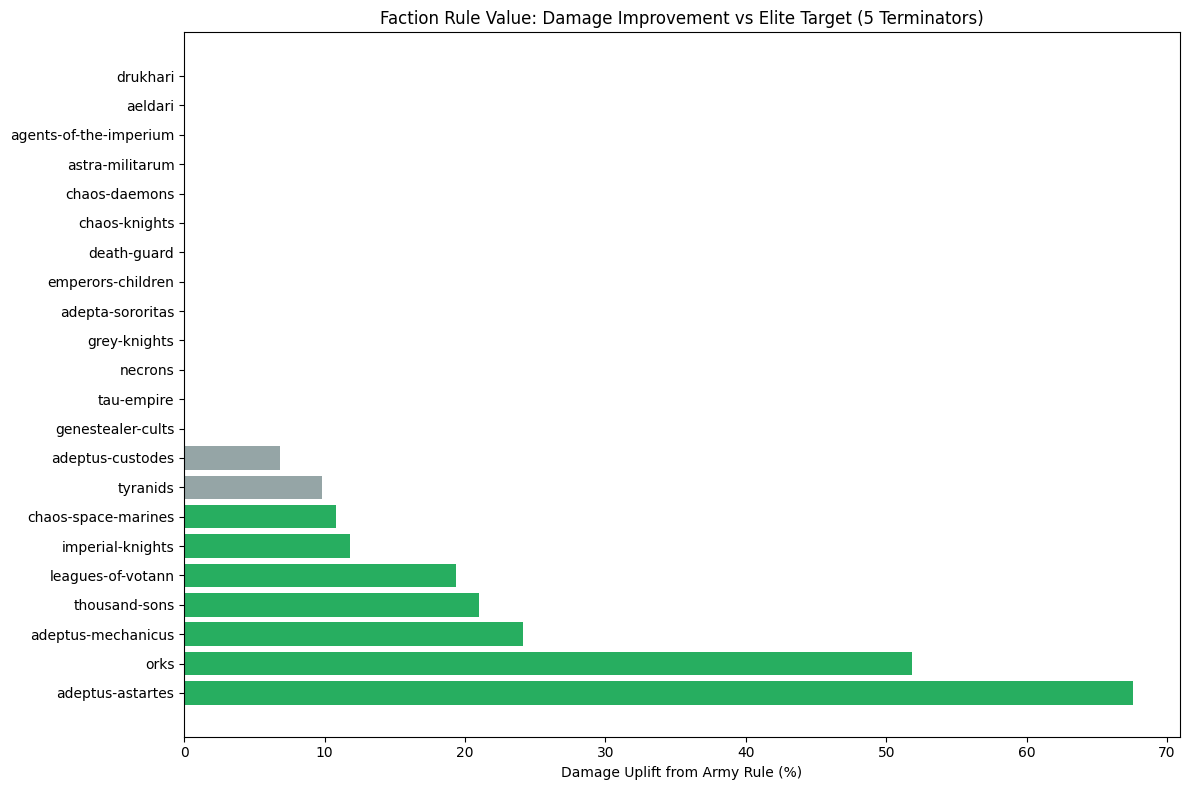

Saved faction_rule_value.png


In [19]:
# === FACTION RULE VALUE ===
# How much of each faction's pricing premium comes from its army rule?
# Compare: damage with army rule ON vs OFF

print("=== FACTION RULE VALUE DECOMPOSITION ===")
print("How much damage does each faction's army rule add per 100pts?\n")

# For each faction, compute average damage with and without the faction rule
faction_rule_impact = []
test_target = ARCHETYPE_TARGETS['elite']  # Use terminators as reference

for faction in sorted(factions_list):
    if faction in ['_example', 'world-eaters']:
        continue
    
    faction_units = [u for u in all_units if u['_faction'] == faction]
    if len(faction_units) < 5:
        continue
    
    dmg_with_rule = []
    dmg_without_rule = []
    
    for u in faction_units[:30]:  # Sample to keep it fast
        points = u.get('points', [])
        if not points: continue
        min_pts = min(points, key=lambda p: p.get('models', 999))
        cost = min_pts.get('cost', 0)
        if cost <= 0: continue
        
        # With faction rule (full DSL buffs)
        buffs_with = dsl_to_buffs(faction, u['id'], 'shooting')
        dmg_w = compute_unit_total_damage(u, faction, test_target, buffs_with, 'shooting')
        
        # Without faction rule (only unit abilities)
        buffs_without = Buffs(assume_stationary=True, assume_half_range=True)
        for ab in dsl_by_unit.get((faction, u['id']), []):
            walk_effect_to_buffs(ab.get('effect'), buffs_without)
        dmg_wo = compute_unit_total_damage(u, faction, test_target, buffs_without, 'shooting')
        
        if dmg_wo > 0:
            dmg_with_rule.append(dmg_w / cost * 100)
            dmg_without_rule.append(dmg_wo / cost * 100)
    
    if len(dmg_with_rule) >= 3:
        avg_with = np.mean(dmg_with_rule)
        avg_without = np.mean(dmg_without_rule)
        uplift = (avg_with / max(avg_without, 0.01) - 1) * 100
        faction_rule_impact.append({
            'faction': faction,
            'dmg_with_rule': avg_with,
            'dmg_without_rule': avg_without,
            'uplift_pct': uplift,
        })

fri = pd.DataFrame(faction_rule_impact).sort_values('uplift_pct', ascending=False)
print(f"{'Faction':<25s} {'With Rule':>10s} {'Without':>10s} {'Uplift':>10s}")
print("-" * 58)
for _, row in fri.iterrows():
    print(f"{row['faction']:<25s} {row['dmg_with_rule']:>10.1f} {row['dmg_without_rule']:>10.1f} {row['uplift_pct']:>+9.0f}%")

# Visualization
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#27ae60' if v > 10 else '#e74c3c' if v < -5 else '#95a5a6' for v in fri['uplift_pct']]
ax.barh(fri['faction'], fri['uplift_pct'], color=colors)
ax.set_xlabel('Damage Uplift from Army Rule (%)')
ax.set_title('Faction Rule Value: Damage Improvement vs Elite Target (5 Terminators)')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig(REPO / 'scripts' / 'faction_rule_value.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved faction_rule_value.png")
